# **0. Import Library**

In [481]:
import os
import tqdm
import math
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

# **1. Data Understanding**

### **1.1. Load Dataset**

In [482]:
BASE_DIR = "../../data/"
dfs = []

for filename in os.listdir(BASE_DIR):
    if filename.endswith(".jsonl"):
        filepath = os.path.join(BASE_DIR, filename)
        try:
            temp_df = pd.read_json(filepath, lines=True)
            if not temp_df.empty:
                dfs.append(temp_df)
        except Exception as e:
            print(f"Melewati {filename} - Error: {e}")

if dfs:
    df = pd.concat(dfs, ignore_index=True)
    print(f"\nBerhasil menggabungkan {len(dfs)} file JSON.")
else:
    df = pd.DataFrame()
    print("\nTidak ada data yang berhasil dimuat.")

df.info()


Berhasil menggabungkan 9 file JSON.
<class 'pandas.DataFrame'>
RangeIndex: 35995 entries, 0 to 35994
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   source            35995 non-null  str                
 1   url               35995 non-null  str                
 2   title             35995 non-null  str                
 3   price_in_rp       35995 non-null  int64              
 4   address           35995 non-null  str                
 5   district          35995 non-null  str                
 6   city              35986 non-null  str                
 7   bedrooms          35544 non-null  float64            
 8   bathrooms         34012 non-null  float64            
 9   building_size_m2  34044 non-null  float64            
 10  land_size_m2      34079 non-null  float64            
 11  carports          13931 non-null  float64            
 12  certificate       32718 non-null  

In [483]:
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"{column}: {unique_values} unique values")
    if df[column].dtype == 'object' and unique_values < 15:
        print(f"   {df[column].unique()}")
        print(f"   Value counts: \n{df[column].value_counts()}\n")
    elif unique_values < 10:
        print(f"   {df[column].unique()}")
        print(f"   Value counts: \n{df[column].value_counts()}\n")

source: 1 unique values
   <StringArray>
['pinhome']
Length: 1, dtype: str
   Value counts: 
source
pinhome    35995
Name: count, dtype: int64

url: 35993 unique values
title: 34182 unique values
price_in_rp: 1854 unique values
address: 88 unique values
district: 87 unique values
city: 9 unique values
   <StringArray>
[         'Kota Bekasi',           'Kota Bogor',           'Kota Depok',
   'Kota Jakarta Barat',   'Kota Jakarta Pusat', 'Kota Jakarta Selatan',
   'Kota Jakarta Timur',   'Kota Jakarta Utara',                    nan,
       'Kota Tangerang']
Length: 10, dtype: str
   Value counts: 
city
Kota Jakarta Barat      4001
Kota Depok              4000
Kota Jakarta Selatan    4000
Kota Jakarta Timur      4000
Kota Tangerang          4000
Kota Bekasi             3998
Kota Bogor              3998
Kota Jakarta Pusat      3998
Kota Jakarta Utara      3991
Name: count, dtype: int64

bedrooms: 56 unique values
bathrooms: 56 unique values
building_size_m2: 786 unique values
land_size_m

In [484]:
# Basic dataset overview
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Total entries: {len(df):,}")
print(f"Total features: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)
print(df.describe())

DATASET OVERVIEW
Dataset shape: (35995, 17)
Total entries: 35,995
Total features: 17
Memory usage: 27.23 MB

BASIC STATISTICS
        price_in_rp      bedrooms     bathrooms  building_size_m2  \
count  3.599500e+04  35544.000000  34012.000000      34044.000000   
mean   5.130375e+09      3.991447      3.018640        211.594319   
std    1.345985e+10      3.612592      2.942393        250.348766   
min    3.000000e+07      1.000000      1.000000          2.000000   
25%    9.500000e+08      3.000000      2.000000         80.000000   
50%    1.950000e+09      3.000000      3.000000        144.000000   
75%    4.300000e+09      5.000000      4.000000        250.000000   
max    4.050000e+11    119.000000    105.000000      10000.000000   

       land_size_m2      carports   electricity  
count  34079.000000  13931.000000  1.507800e+04  
mean     200.974207      1.732754  4.564548e+03  
std      270.704518      8.555390  3.782365e+04  
min        2.000000      1.000000  2.500000e+02  
25

### **1.2. Missing Values Analysis**

MISSING VALUES ANALYSIS
📊 9 columns have missing values:

Detailed breakdown:
  • carports                 : 22064 ( 61.3%)
  • electricity              : 20917 ( 58.1%)
  • certificate              :  3277 (  9.1%)
  • bathrooms                :  1983 (  5.5%)
  • building_size_m2         :  1951 (  5.4%)
  • land_size_m2             :  1916 (  5.3%)
  • furnishing               :  1838 (  5.1%)
  • bedrooms                 :   451 (  1.3%)
  • city                     :     9 (  0.0%)


C:\Users\Baraja\AppData\Local\Temp\ipykernel_6500\477394975.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, x='Missing_Percentage', y='Column', palette='viridis')


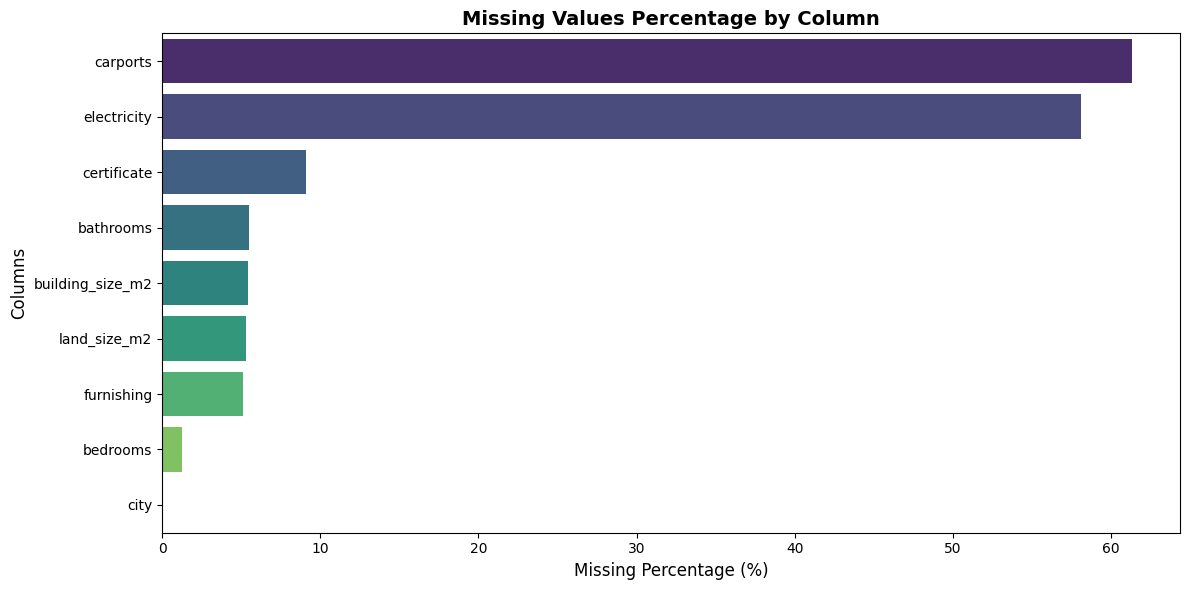

In [485]:
# Missing values analysis
def analyze_missing_values(df):
    """Comprehensive missing values analysis"""
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Column': missing_data.index,
        'Missing_Count': missing_data.values,
        'Missing_Percentage': missing_percent.values
    })
    
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
    
    print("="*60)
    print("MISSING VALUES ANALYSIS")
    print("="*60)
    
    if len(missing_df) == 0:
        print("✅ No missing values found in the dataset!")
    else:
        print(f"📊 {len(missing_df)} columns have missing values:")
        print("\nDetailed breakdown:")
        for _, row in missing_df.iterrows():
            print(f"  • {row['Column']:25s}: {row['Missing_Count']:5.0f} ({row['Missing_Percentage']:5.1f}%)")
        
        # Visualization
        if len(missing_df) > 0:
            plt.figure(figsize=(12, 6))
            sns.barplot(data=missing_df, x='Missing_Percentage', y='Column', palette='viridis')
            plt.title('Missing Values Percentage by Column', fontsize=14, fontweight='bold')
            plt.xlabel('Missing Percentage (%)', fontsize=12)
            plt.ylabel('Columns', fontsize=12)
            plt.tight_layout()
            plt.show()
    
    return missing_df

missing_analysis = analyze_missing_values(df)

### **1.3. Target Variable Analysis (Price)**

PRICE DISTRIBUTION ANALYSIS
Basic Statistics:
  • Count: 35,995
  • Mean: Rp 5,130,374,726
  • Median: Rp 1,950,000,000
  • Std: Rp 13,459,846,401
  • Min: Rp 30,000,000
  • Max: Rp 405,000,000,000

Quartiles:
  • Q1 (25%): Rp 950,000,000
  • Q3 (75%): Rp 4,300,000,000
  • IQR: Rp 3,350,000,000

Price Ranges:
  • Budget (< 1B): 9,718 (27.0%)
  • Mid-range (1B-3B): 13,375 (37.2%)
  • Premium (3B-10B): 9,316 (25.9%)
  • Luxury (> 10B): 3,586 (10.0%)


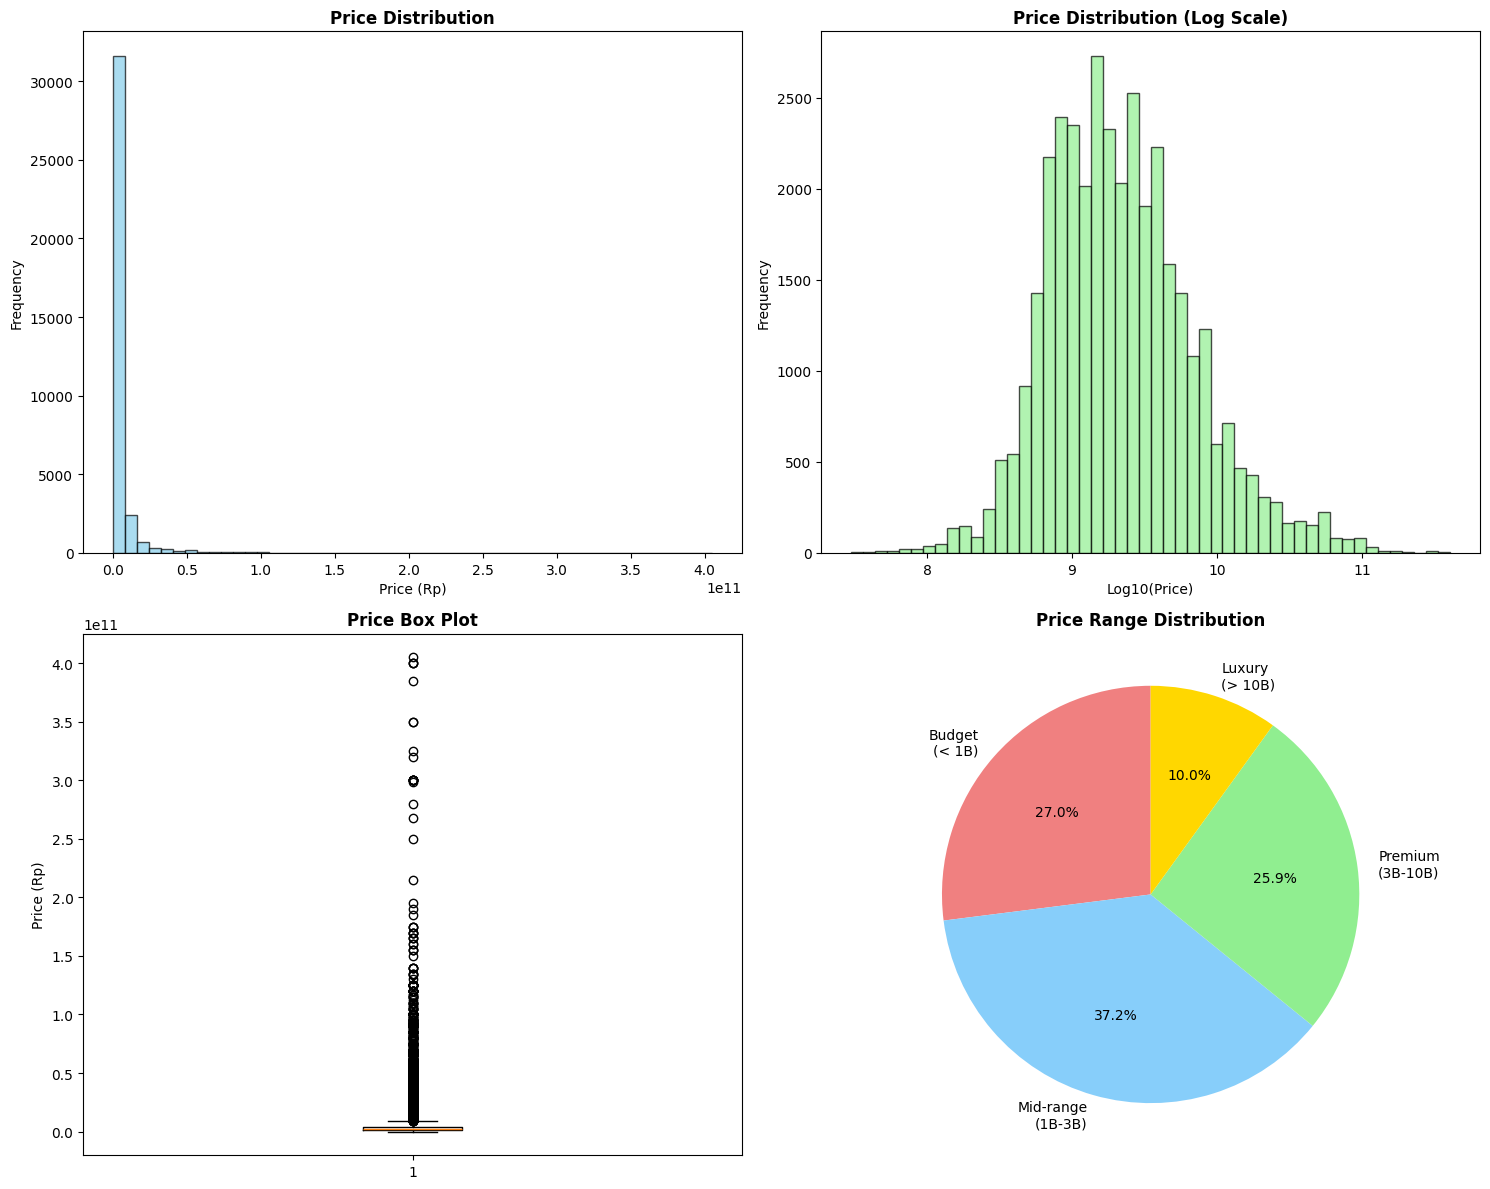

In [486]:
# Target variable (Price) analysis
def analyze_price_distribution(df):
    """Analyze the distribution of house prices"""
    price_col = 'price_in_rp'
    
    print("="*60)
    print("PRICE DISTRIBUTION ANALYSIS")
    print("="*60)
    
    # Basic statistics
    print("Basic Statistics:")
    print(f"  • Count: {df[price_col].count():,}")
    print(f"  • Mean: Rp {df[price_col].mean():,.0f}")
    print(f"  • Median: Rp {df[price_col].median():,.0f}")
    print(f"  • Std: Rp {df[price_col].std():,.0f}")
    print(f"  • Min: Rp {df[price_col].min():,.0f}")
    print(f"  • Max: Rp {df[price_col].max():,.0f}")
    
    # Quartiles
    q1 = df[price_col].quantile(0.25)
    q3 = df[price_col].quantile(0.75)
    iqr = q3 - q1
    
    print(f"\nQuartiles:")
    print(f"  • Q1 (25%): Rp {q1:,.0f}")
    print(f"  • Q3 (75%): Rp {q3:,.0f}")
    print(f"  • IQR: Rp {iqr:,.0f}")
    
    # Price ranges
    print(f"\nPrice Ranges:")
    budget = df[df[price_col] < 1e9].shape[0]
    mid_range = df[(df[price_col] >= 1e9) & (df[price_col] < 3e9)].shape[0]
    premium = df[(df[price_col] >= 3e9) & (df[price_col] < 10e9)].shape[0]
    luxury = df[df[price_col] >= 10e9].shape[0]
    
    total = len(df)
    print(f"  • Budget (< 1B): {budget:,} ({budget/total*100:.1f}%)")
    print(f"  • Mid-range (1B-3B): {mid_range:,} ({mid_range/total*100:.1f}%)")
    print(f"  • Premium (3B-10B): {premium:,} ({premium/total*100:.1f}%)")
    print(f"  • Luxury (> 10B): {luxury:,} ({luxury/total*100:.1f}%)")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Histogram
    axes[0,0].hist(df[price_col], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0,0].set_title('Price Distribution', fontweight='bold')
    axes[0,0].set_xlabel('Price (Rp)')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
    
    # Log-scale histogram
    axes[0,1].hist(np.log10(df[price_col]), bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[0,1].set_title('Price Distribution (Log Scale)', fontweight='bold')
    axes[0,1].set_xlabel('Log10(Price)')
    axes[0,1].set_ylabel('Frequency')
    
    # Box plot
    axes[1,0].boxplot(df[price_col])
    axes[1,0].set_title('Price Box Plot', fontweight='bold')
    axes[1,0].set_ylabel('Price (Rp)')
    axes[1,0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # Price ranges pie chart
    sizes = [budget, mid_range, premium, luxury]
    labels = ['Budget\n(< 1B)', 'Mid-range\n(1B-3B)', 'Premium\n(3B-10B)', 'Luxury\n(> 10B)']
    colors = ['lightcoral', 'lightskyblue', 'lightgreen', 'gold']
    
    axes[1,1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[1,1].set_title('Price Range Distribution', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

analyze_price_distribution(df)

### **1.4. Categorical Variables Analysis**

C:\Users\Baraja\AppData\Local\Temp\ipykernel_6500\2733763780.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


CATEGORICAL VARIABLES ANALYSIS
Found 9 categorical columns:
  • source: 1 unique values
  • url: 35993 unique values
  • title: 34182 unique values
  • address: 88 unique values
  • district: 87 unique values
  • city: 9 unique values
  • certificate: 2 unique values
  • furnishing: 3 unique values
  • hash_id: 35995 unique values


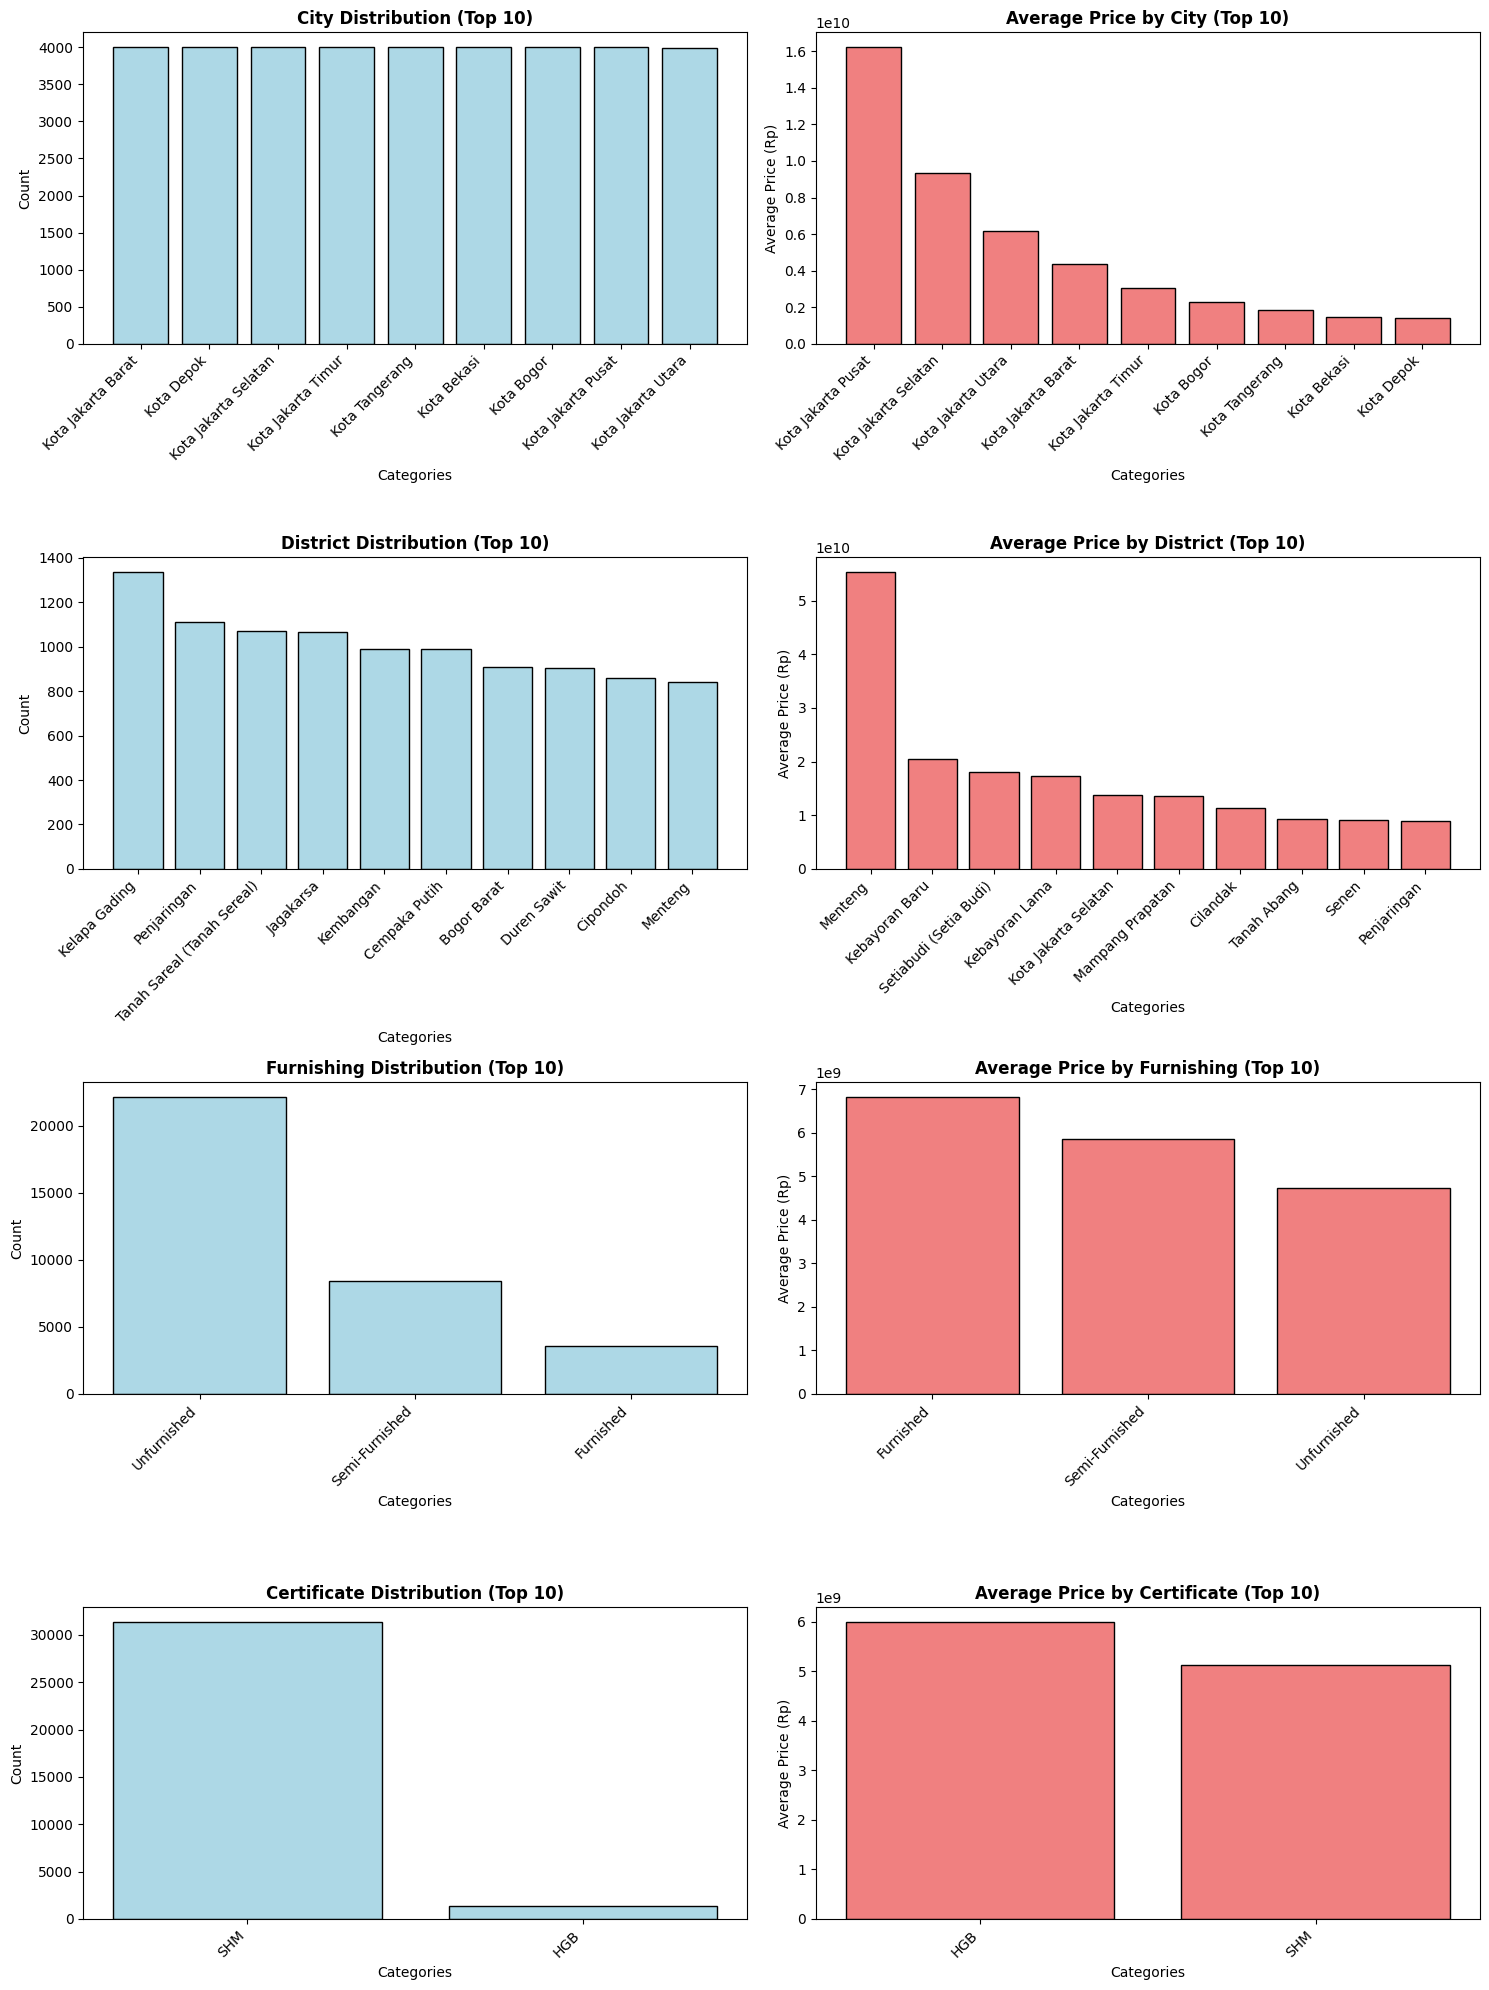

In [487]:
# Categorical variables analysis
def analyze_categorical_variables(df):
    """Analyze categorical variables and their relationship with price"""
    
    categorical_cols = df.select_dtypes(include=['object']).columns
    
    print("="*60)
    print("CATEGORICAL VARIABLES ANALYSIS")
    print("="*60)
    print(f"Found {len(categorical_cols)} categorical columns:")
    
    for col in categorical_cols:
        unique_count = df[col].nunique()
        print(f"  • {col}: {unique_count} unique values")
    
    # Analyze key categorical variables
    key_categorical = ['city', 'district', 'furnishing', 'certificate']
    available_cats = [col for col in key_categorical if col in df.columns]
    
    if available_cats:
        fig, axes = plt.subplots(len(available_cats), 2, figsize=(15, 5*len(available_cats)))
        if len(available_cats) == 1:
            axes = axes.reshape(1, -1)
        
        for i, col in enumerate(available_cats):
            if col in df.columns:
                # Value counts
                value_counts = df[col].value_counts().head(10)
                
                # Count plot
                axes[i,0].bar(range(len(value_counts)), value_counts.values, color='lightblue', edgecolor='black')
                axes[i,0].set_title(f'{col.title()} Distribution (Top 10)', fontweight='bold')
                axes[i,0].set_xlabel('Categories')
                axes[i,0].set_ylabel('Count')
                axes[i,0].set_xticks(range(len(value_counts)))
                axes[i,0].set_xticklabels(value_counts.index, rotation=45, ha='right')
                
                # Average price by category
                if 'price_in_rp' in df.columns:
                    avg_price = df.groupby(col)['price_in_rp'].mean().sort_values(ascending=False).head(10)
                    axes[i,1].bar(range(len(avg_price)), avg_price.values, color='lightcoral', edgecolor='black')
                    axes[i,1].set_title(f'Average Price by {col.title()} (Top 10)', fontweight='bold')
                    axes[i,1].set_xlabel('Categories')
                    axes[i,1].set_ylabel('Average Price (Rp)')
                    axes[i,1].set_xticks(range(len(avg_price)))
                    axes[i,1].set_xticklabels(avg_price.index, rotation=45, ha='right')
                    axes[i,1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        
        plt.tight_layout()
        plt.show()

analyze_categorical_variables(df)

### **1.5. Numerical Variables Analysis**

NUMERICAL VARIABLES ANALYSIS
Found 6 numerical columns (excluding price):
  • bedrooms
  • bathrooms
  • building_size_m2
  • land_size_m2
  • carports
  • electricity

Detailed Statistics:
           bedrooms     bathrooms  building_size_m2  land_size_m2  \
count  35544.000000  34012.000000      34044.000000  34079.000000   
mean       3.991447      3.018640        211.594319    200.974207   
std        3.612592      2.942393        250.348766    270.704518   
min        1.000000      1.000000          2.000000      2.000000   
25%        3.000000      2.000000         80.000000     77.000000   
50%        3.000000      3.000000        144.000000    120.000000   
75%        5.000000      4.000000        250.000000    216.000000   
max      119.000000    105.000000      10000.000000  10000.000000   

           carports   electricity  
count  13931.000000  1.507800e+04  
mean       1.732754  4.564548e+03  
std        8.555390  3.782365e+04  
min        1.000000  2.500000e+02  
25%     

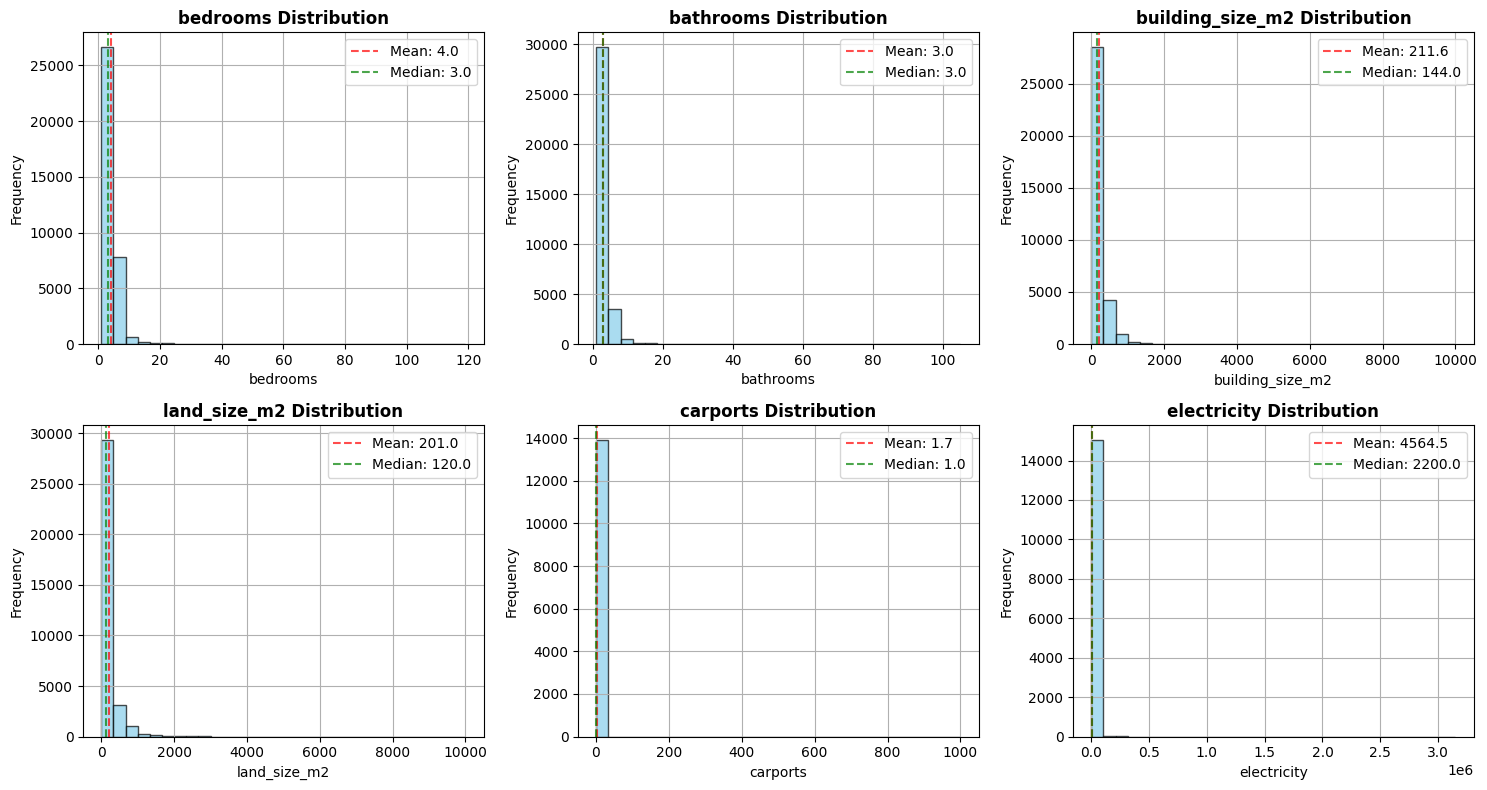

In [488]:
# Numerical variables analysis
def analyze_numerical_variables(df):
    """Analyze numerical variables and their distributions"""
    
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    numerical_cols = [col for col in numerical_cols if col != 'price_in_rp']  # Exclude target
    
    print("="*60)
    print("NUMERICAL VARIABLES ANALYSIS")
    print("="*60)
    print(f"Found {len(numerical_cols)} numerical columns (excluding price):")
    
    for col in numerical_cols:
        print(f"  • {col}")
    
    # Basic statistics
    print(f"\nDetailed Statistics:")
    print(df[numerical_cols].describe())
    
    # Distribution plots
    n_cols = 3
    n_rows = math.ceil(len(numerical_cols) / n_cols)
    
    if len(numerical_cols) > 0:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
        
        for i, col in enumerate(numerical_cols):
            if i < len(axes):
                # Histogram with KDE
                df[col].hist(bins=30, alpha=0.7, ax=axes[i], edgecolor='black', color='skyblue')
                axes[i].set_title(f'{col} Distribution', fontweight='bold')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Frequency')
                
                # Add statistics text
                mean_val = df[col].mean()
                median_val = df[col].median()
                axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.1f}')
                axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.7, label=f'Median: {median_val:.1f}')
                axes[i].legend()
        
        # Hide empty subplots
        for i in range(len(numerical_cols), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()

analyze_numerical_variables(df)

### **1.6. Correlation Analysis**

CORRELATION ANALYSIS
Correlations with Price (sorted by strength):
  • building_size_m2    :  0.567 🟡 Moderate
  • land_size_m2        :  0.558 🟡 Moderate
  • bathrooms           :  0.253 ⚪ Very Weak
  • electricity         :  0.222 ⚪ Very Weak
  • bedrooms            :  0.202 ⚪ Very Weak
  • carports            :  0.056 ⚪ Very Weak


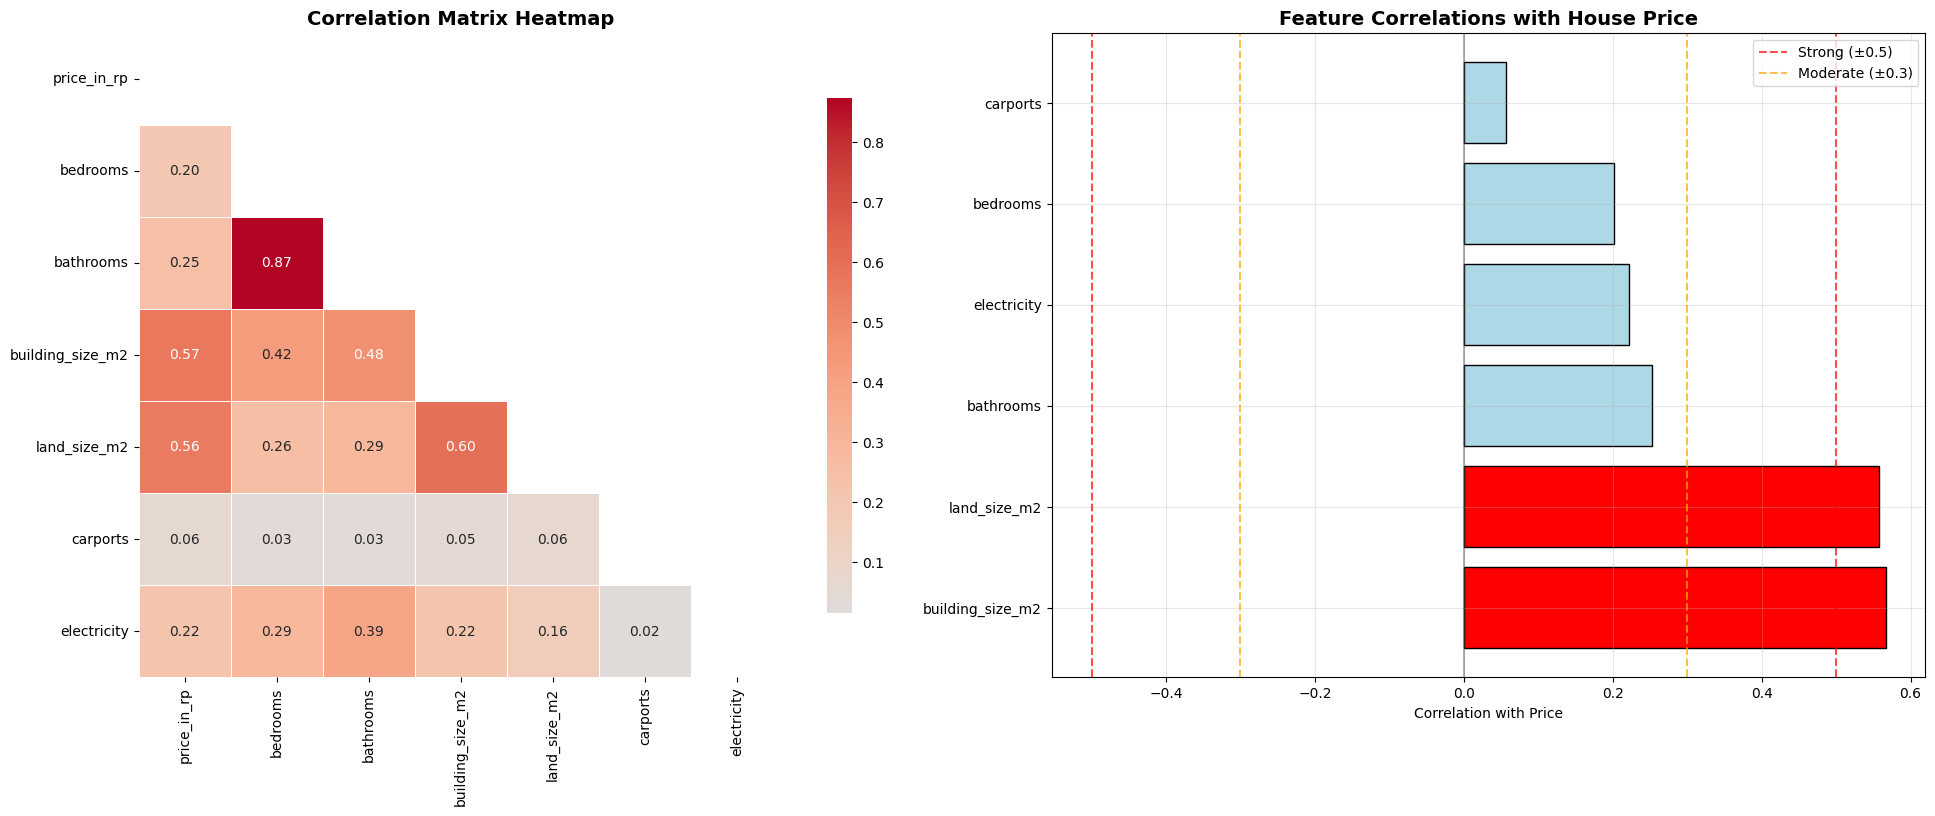


🔍 Multicollinearity Check (|correlation| > 0.8):
  ⚠️  bedrooms ↔ bathrooms: 0.874


In [489]:
# Correlation analysis
def analyze_correlations(df):
    """Analyze correlations between numerical variables and price"""
    
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    
    if 'price_in_rp' in numerical_cols:
        print("="*60)
        print("CORRELATION ANALYSIS")
        print("="*60)
        
        # Calculate correlations
        correlation_matrix = df[numerical_cols].corr()
        
        # Correlations with price
        price_correlations = correlation_matrix['price_in_rp'].sort_values(ascending=False)
        
        print("Correlations with Price (sorted by strength):")
        for var, corr in price_correlations.items():
            if var != 'price_in_rp':
                strength = ""
                if abs(corr) >= 0.7:
                    strength = "🔴 Strong"
                elif abs(corr) >= 0.5:
                    strength = "🟡 Moderate"
                elif abs(corr) >= 0.3:
                    strength = "🟢 Weak"
                else:
                    strength = "⚪ Very Weak"
                
                print(f"  • {var:20s}: {corr:6.3f} {strength}")
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        
        # Full correlation heatmap
        mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
        sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
                   cmap='coolwarm', center=0, ax=axes[0],
                   square=True, linewidths=0.5, cbar_kws={"shrink": .8})
        axes[0].set_title('Correlation Matrix Heatmap', fontweight='bold', fontsize=14)
        
        # Price correlations bar plot
        price_corr_filtered = price_correlations.drop('price_in_rp')
        colors = ['red' if abs(x) >= 0.5 else 'orange' if abs(x) >= 0.3 else 'lightblue' for x in price_corr_filtered.values]
        
        axes[1].barh(range(len(price_corr_filtered)), price_corr_filtered.values, color=colors, edgecolor='black')
        axes[1].set_yticks(range(len(price_corr_filtered)))
        axes[1].set_yticklabels(price_corr_filtered.index)
        axes[1].set_xlabel('Correlation with Price')
        axes[1].set_title('Feature Correlations with House Price', fontweight='bold', fontsize=14)
        axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
        axes[1].grid(True, alpha=0.3)
        
        # Add correlation strength lines
        axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Strong (±0.5)')
        axes[1].axvline(x=-0.5, color='red', linestyle='--', alpha=0.7)
        axes[1].axvline(x=0.3, color='orange', linestyle='--', alpha=0.7, label='Moderate (±0.3)')
        axes[1].axvline(x=-0.3, color='orange', linestyle='--', alpha=0.7)
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Identify highly correlated feature pairs (multicollinearity check)
        print(f"\n🔍 Multicollinearity Check (|correlation| > 0.8):")
        high_corr_pairs = []
        
        for i in range(len(correlation_matrix.columns)):
            for j in range(i+1, len(correlation_matrix.columns)):
                col1 = correlation_matrix.columns[i]
                col2 = correlation_matrix.columns[j]
                corr_val = correlation_matrix.iloc[i, j]
                
                if abs(corr_val) > 0.8:
                    high_corr_pairs.append((col1, col2, corr_val))
        
        if high_corr_pairs:
            for col1, col2, corr in high_corr_pairs:
                print(f"  ⚠️  {col1} ↔ {col2}: {corr:.3f}")
        else:
            print("  ✅ No high multicollinearity detected")

analyze_correlations(df)

# **2. Data Preparation**

### **2.1. Data Selection**

In [490]:
dropped_df = df.drop(['source', 'url', 'title', 'address', 'scraped_at', 'hash_id'], axis=1)
dropped_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35995 entries, 0 to 35994
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       35995 non-null  int64  
 1   district          35995 non-null  str    
 2   city              35986 non-null  str    
 3   bedrooms          35544 non-null  float64
 4   bathrooms         34012 non-null  float64
 5   building_size_m2  34044 non-null  float64
 6   land_size_m2      34079 non-null  float64
 7   carports          13931 non-null  float64
 8   certificate       32718 non-null  str    
 9   furnishing        34157 non-null  str    
 10  electricity       15078 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 3.0 MB


In [491]:
for column in dropped_df.columns:
    unique_values = dropped_df[column].nunique()
    print(f"{column}: {unique_values} unique values")
    if dropped_df[column].dtype == 'object' and unique_values < 15:
        print(f"   {dropped_df[column].unique()}")
        print(f"   Value counts: \n{dropped_df[column].value_counts()}\n")
    elif unique_values < 10:
        print(f"   {dropped_df[column].unique()}")
        print(f"   Value counts: \n{dropped_df[column].value_counts()}\n")

price_in_rp: 1854 unique values
district: 87 unique values
city: 9 unique values
   <StringArray>
[         'Kota Bekasi',           'Kota Bogor',           'Kota Depok',
   'Kota Jakarta Barat',   'Kota Jakarta Pusat', 'Kota Jakarta Selatan',
   'Kota Jakarta Timur',   'Kota Jakarta Utara',                    nan,
       'Kota Tangerang']
Length: 10, dtype: str
   Value counts: 
city
Kota Jakarta Barat      4001
Kota Depok              4000
Kota Jakarta Selatan    4000
Kota Jakarta Timur      4000
Kota Tangerang          4000
Kota Bekasi             3998
Kota Bogor              3998
Kota Jakarta Pusat      3998
Kota Jakarta Utara      3991
Name: count, dtype: int64

bedrooms: 56 unique values
bathrooms: 56 unique values
building_size_m2: 786 unique values
land_size_m2: 1119 unique values
carports: 16 unique values
certificate: 2 unique values
   <StringArray>
['SHM', 'HGB', nan]
Length: 3, dtype: str
   Value counts: 
certificate
SHM    31361
HGB     1357
Name: count, dtype: int64

fu

### **2.2. Cleaning Data**

2.2.1. Drop Duplicated Data

In [492]:
duplicated_count = dropped_df.duplicated().sum()
duplicated_count

np.int64(1862)

In [493]:
dropped_df = dropped_df.drop_duplicates()
dropped_df.info()

<class 'pandas.DataFrame'>
Index: 34133 entries, 0 to 35994
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       34133 non-null  int64  
 1   district          34133 non-null  str    
 2   city              34124 non-null  str    
 3   bedrooms          33727 non-null  float64
 4   bathrooms         32213 non-null  float64
 5   building_size_m2  32248 non-null  float64
 6   land_size_m2      32297 non-null  float64
 7   carports          13480 non-null  float64
 8   certificate       31048 non-null  str    
 9   furnishing        32368 non-null  str    
 10  electricity       14687 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 3.1 MB


2.2.2. Handle Missing Values

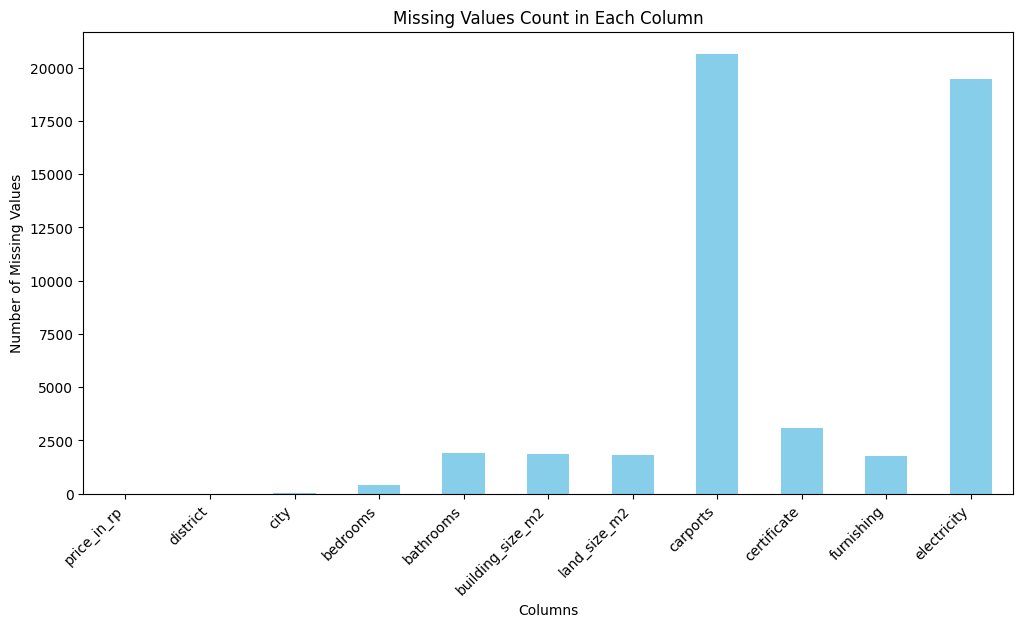

In [494]:
def show_is_null_plot(df):
    nan_counts = df.isnull().sum()
    plt.figure(figsize=(12, 6))
    nan_counts.plot(kind='bar', color='skyblue')
    plt.title('Missing Values Count in Each Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.show()

show_is_null_plot(dropped_df)

A. Handle Less Missing Values in Columns

In [495]:
less_nan = dropped_df[dropped_df['district'].isna() | dropped_df['city'].isna() | dropped_df['bedrooms'].isna() | dropped_df['bathrooms'].isna() | dropped_df['land_size_m2'].isna() | dropped_df['building_size_m2'].isna()]
less_nan

,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,carports,certificate,furnishing,electricity
1,1400000000,Medansatria (Medan Satria),Kota Bekasi,3.0,NaN,150.0,112.0,2.0,SHM,Semi-Furnished,2200.0
9,885000000,Jatiasih,Kota Bekasi,3.0,2.0,NaN,83.0,2.0,SHM,Unfurnished,2200.0
16,932645000,Rawalumbu,Kota Bekasi,NaN,NaN,NaN,NaN,NaN,SHM,NaN,NaN
18,824500000,Jatiasih,Kota Bekasi,NaN,NaN,NaN,NaN,NaN,SHM,NaN,NaN
20,517000000,Mustikajaya (Mustika Jaya),Kota Bekasi,NaN,NaN,NaN,NaN,NaN,SHM,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
35910,3400000000,Cibodas,Kota Tangerang,4.0,3.0,NaN,582.0,2.0,SHM,Unfurnished,5500.0
35911,1450000000,Pinang (Penang),Kota Tangerang,2.0,1.0,90.0,NaN,2.0,SHM,Unfurnished,2200.0
35941,800000000,Pinang (Penang),Kota Tangerang,4.0,2.0,170.0,NaN,1.0,SHM,Unfurnished,1300.0
35967,1800000000,Larangan,Kota Tangerang,4.0,2.0,NaN,161.0,2.0,SHM,Semi-Furnished,2200.0


In [496]:
dropped_df = dropped_df.drop(less_nan.index, axis=0)
dropped_df.info()

<class 'pandas.DataFrame'>
Index: 29280 entries, 0 to 35994
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       29280 non-null  int64  
 1   district          29280 non-null  str    
 2   city              29280 non-null  str    
 3   bedrooms          29280 non-null  float64
 4   bathrooms         29280 non-null  float64
 5   building_size_m2  29280 non-null  float64
 6   land_size_m2      29280 non-null  float64
 7   carports          9072 non-null   float64
 8   certificate       26506 non-null  str    
 9   furnishing        27915 non-null  str    
 10  electricity       10246 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.7 MB


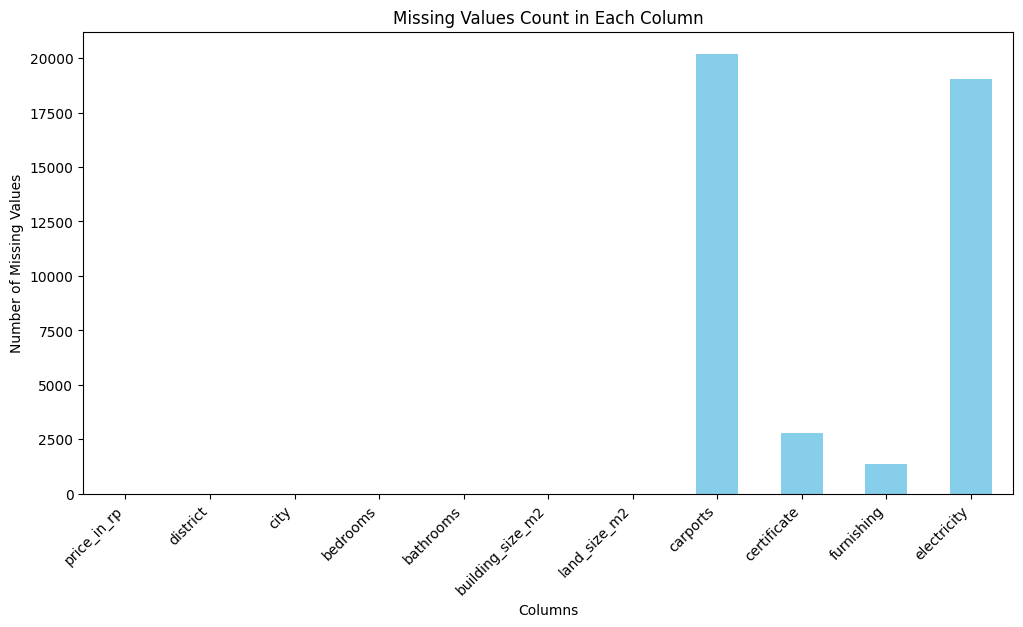

In [497]:
show_is_null_plot(dropped_df)

B. Fill with Most Frequent for Categorical Columns

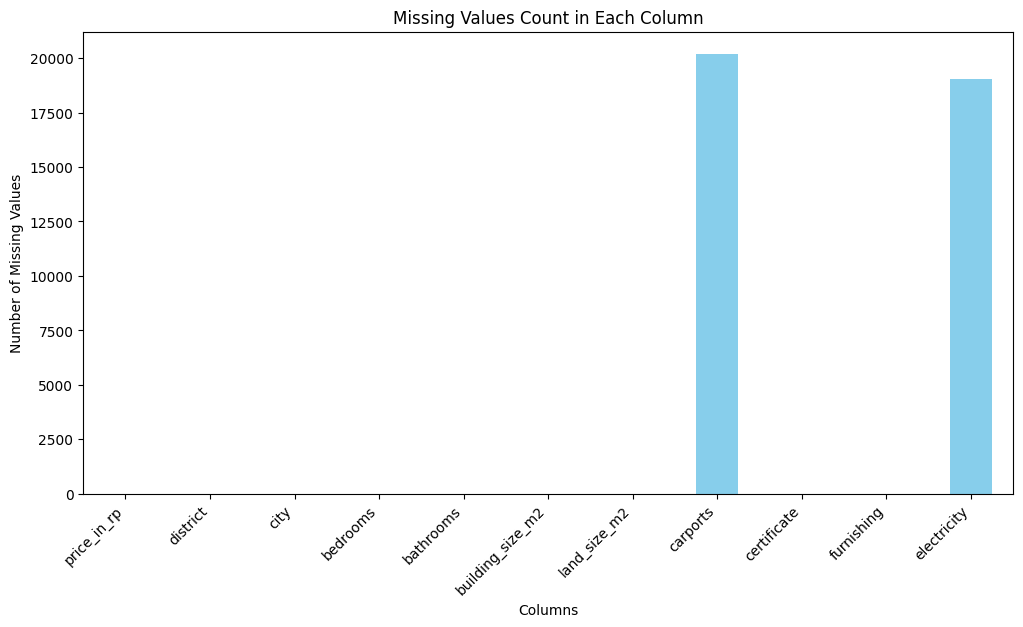

In [498]:
categorical_features = ['district', 'city', 'certificate', 'furnishing']

imputer_cat = SimpleImputer(strategy='most_frequent')
dropped_df[categorical_features] = imputer_cat.fit_transform(dropped_df[categorical_features])

show_is_null_plot(dropped_df)

C. Handle Column with >40% Null Values

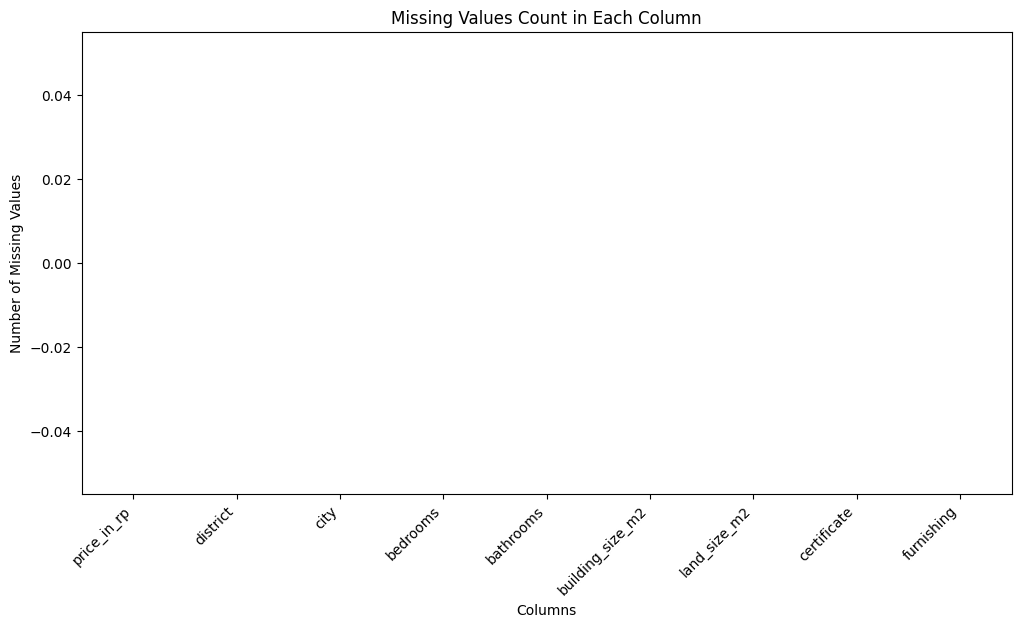

In [499]:
dropped_df = dropped_df.drop(['electricity', 'carports'], axis=1)

show_is_null_plot(dropped_df)

### **2.3. Encoding Categorical Values**

In [500]:
encoded_df = dropped_df.copy()
encoded_df.info()

<class 'pandas.DataFrame'>
Index: 29280 entries, 0 to 35994
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_in_rp       29280 non-null  int64  
 1   district          29280 non-null  str    
 2   city              29280 non-null  str    
 3   bedrooms          29280 non-null  float64
 4   bathrooms         29280 non-null  float64
 5   building_size_m2  29280 non-null  float64
 6   land_size_m2      29280 non-null  float64
 7   certificate       29280 non-null  str    
 8   furnishing        29280 non-null  str    
dtypes: float64(4), int64(1), str(4)
memory usage: 2.2 MB


2.3.1. Encoding Furnishing

In [501]:
furnishing_ordinal = encoded_df['furnishing'].unique()
furnishing_ordinal

<StringArray>
['Unfurnished', 'Semi-Furnished', 'Furnished']
Length: 3, dtype: str

In [502]:
furnishing_encoder = OrdinalEncoder(categories=[furnishing_ordinal], dtype=int)
encoded_df['furnishing_encoded'] = furnishing_encoder.fit_transform(encoded_df[['furnishing']])
encoded_df.head()

,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,certificate,furnishing,furnishing_encoded
0,1343000000,Mustikajaya (Mustika Jaya),Kota Bekasi,2.0,1.0,39.0,70.0,SHM,Unfurnished,0
2,2290000000,Medansatria (Medan Satria),Kota Bekasi,2.0,1.0,48.0,40.0,HGB,Unfurnished,0
3,1800000000,Bekasi Barat,Kota Bekasi,3.0,2.0,110.0,90.0,SHM,Semi-Furnished,1
4,949500000,Rawalumbu,Kota Bekasi,3.0,2.0,70.0,63.0,SHM,Unfurnished,0
5,1440000000,Pondokgede (Pondok Gede),Kota Bekasi,3.0,3.0,108.0,91.0,SHM,Unfurnished,0


2.3.2. Encoding City

In [503]:
city_label = encoded_df['city'].unique()
city_label

<StringArray>
[         'Kota Bekasi',           'Kota Bogor',           'Kota Depok',
   'Kota Jakarta Barat',   'Kota Jakarta Pusat', 'Kota Jakarta Selatan',
   'Kota Jakarta Timur',   'Kota Jakarta Utara',       'Kota Tangerang']
Length: 9, dtype: str

In [504]:
city_encoder = LabelEncoder()
encoded_df['city_encoded'] = city_encoder.fit_transform(encoded_df[['city']])
encoded_df.head()

d:\KARYA TULIS\HKI\HomeIQ\backend\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,certificate,furnishing,furnishing_encoded,city_encoded
0,1343000000,Mustikajaya (Mustika Jaya),Kota Bekasi,2.0,1.0,39.0,70.0,SHM,Unfurnished,0,0
2,2290000000,Medansatria (Medan Satria),Kota Bekasi,2.0,1.0,48.0,40.0,HGB,Unfurnished,0,0
3,1800000000,Bekasi Barat,Kota Bekasi,3.0,2.0,110.0,90.0,SHM,Semi-Furnished,1,0
4,949500000,Rawalumbu,Kota Bekasi,3.0,2.0,70.0,63.0,SHM,Unfurnished,0,0
5,1440000000,Pondokgede (Pondok Gede),Kota Bekasi,3.0,3.0,108.0,91.0,SHM,Unfurnished,0,0


2.3.3. Encoding District

In [505]:
district_label = encoded_df['district'].unique()
district_label

<StringArray>
[  'Mustikajaya (Mustika Jaya)',   'Medansatria (Medan Satria)',
                 'Bekasi Barat',                    'Rawalumbu',
     'Pondokgede (Pondok Gede)',                 'Bekasi Timur',
                     'Jatiasih', 'Jatisampurna (Jati Sampurna)',
 'Pondokmelati (Pondok Melati)',                 'Bekasi Utara',
               'Bekasi Selatan', 'Bantargebang (Bantar Gebang)',
                  'Bogor Utara',                'Bogor Selatan',
                  'Bogor Barat',  'Tanah Sareal (Tanah Sereal)',
                  'Bogor Timur',                 'Bogor Tengah',
                     'Sawangan',                       'Cinere',
                     'Cipayung',                   'Bojongsari',
                         'Limo',                    'Cimanggis',
                 'Pancoran Mas',                         'Beji',
                     'Cilodong',                    'Sukmajaya',
                        'Tapos',                'Gunung Sindur',
           

In [506]:
district_encoder = LabelEncoder()
encoded_df['district_encoded'] = district_encoder.fit_transform(encoded_df[['district']])
encoded_df.head()

d:\KARYA TULIS\HKI\HomeIQ\backend\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,certificate,furnishing,furnishing_encoded,city_encoded,district_encoded
0,1343000000,Mustikajaya (Mustika Jaya),Kota Bekasi,2.0,1.0,39.0,70.0,SHM,Unfurnished,0,0,56
2,2290000000,Medansatria (Medan Satria),Kota Bekasi,2.0,1.0,48.0,40.0,HGB,Unfurnished,0,0,54
3,1800000000,Bekasi Barat,Kota Bekasi,3.0,2.0,110.0,90.0,SHM,Semi-Furnished,1,0,3
4,949500000,Rawalumbu,Kota Bekasi,3.0,2.0,70.0,63.0,SHM,Unfurnished,0,0,71
5,1440000000,Pondokgede (Pondok Gede),Kota Bekasi,3.0,3.0,108.0,91.0,SHM,Unfurnished,0,0,68


2.3.2. Encoding Certificate

In [507]:
certificate_label = encoded_df['certificate'].unique()
certificate_label

<StringArray>
['SHM', 'HGB']
Length: 2, dtype: str

In [508]:
certificate_encoder = LabelEncoder()
encoded_df['certificate_encoded'] = certificate_encoder.fit_transform(encoded_df[['certificate']])
encoded_df.head()

d:\KARYA TULIS\HKI\HomeIQ\backend\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,price_in_rp,district,city,bedrooms,bathrooms,building_size_m2,land_size_m2,certificate,furnishing,furnishing_encoded,city_encoded,district_encoded,certificate_encoded
0,1343000000,Mustikajaya (Mustika Jaya),Kota Bekasi,2.0,1.0,39.0,70.0,SHM,Unfurnished,0,0,56,1
2,2290000000,Medansatria (Medan Satria),Kota Bekasi,2.0,1.0,48.0,40.0,HGB,Unfurnished,0,0,54,0
3,1800000000,Bekasi Barat,Kota Bekasi,3.0,2.0,110.0,90.0,SHM,Semi-Furnished,1,0,3,1
4,949500000,Rawalumbu,Kota Bekasi,3.0,2.0,70.0,63.0,SHM,Unfurnished,0,0,71,1
5,1440000000,Pondokgede (Pondok Gede),Kota Bekasi,3.0,3.0,108.0,91.0,SHM,Unfurnished,0,0,68,1


### **2.4. Handle Outliers**

In [509]:
filtered_df = encoded_df[
    (encoded_df['price_in_rp'] >= 3e8) & (encoded_df['price_in_rp'] <= 5e10) & 
    (encoded_df['bedrooms'] <= 20) & (encoded_df['bathrooms'] <= 20) &
    (encoded_df['building_size_m2'] <= 2000) & (encoded_df['land_size_m2'] <= 2000)
]
filtered_df.info()

<class 'pandas.DataFrame'>
Index: 27966 entries, 0 to 35994
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price_in_rp          27966 non-null  int64  
 1   district             27966 non-null  str    
 2   city                 27966 non-null  str    
 3   bedrooms             27966 non-null  float64
 4   bathrooms            27966 non-null  float64
 5   building_size_m2     27966 non-null  float64
 6   land_size_m2         27966 non-null  float64
 7   certificate          27966 non-null  str    
 8   furnishing           27966 non-null  str    
 9   furnishing_encoded   27966 non-null  int64  
 10  city_encoded         27966 non-null  int64  
 11  district_encoded     27966 non-null  int64  
 12  certificate_encoded  27966 non-null  int64  
dtypes: float64(4), int64(5), str(4)
memory usage: 3.0 MB


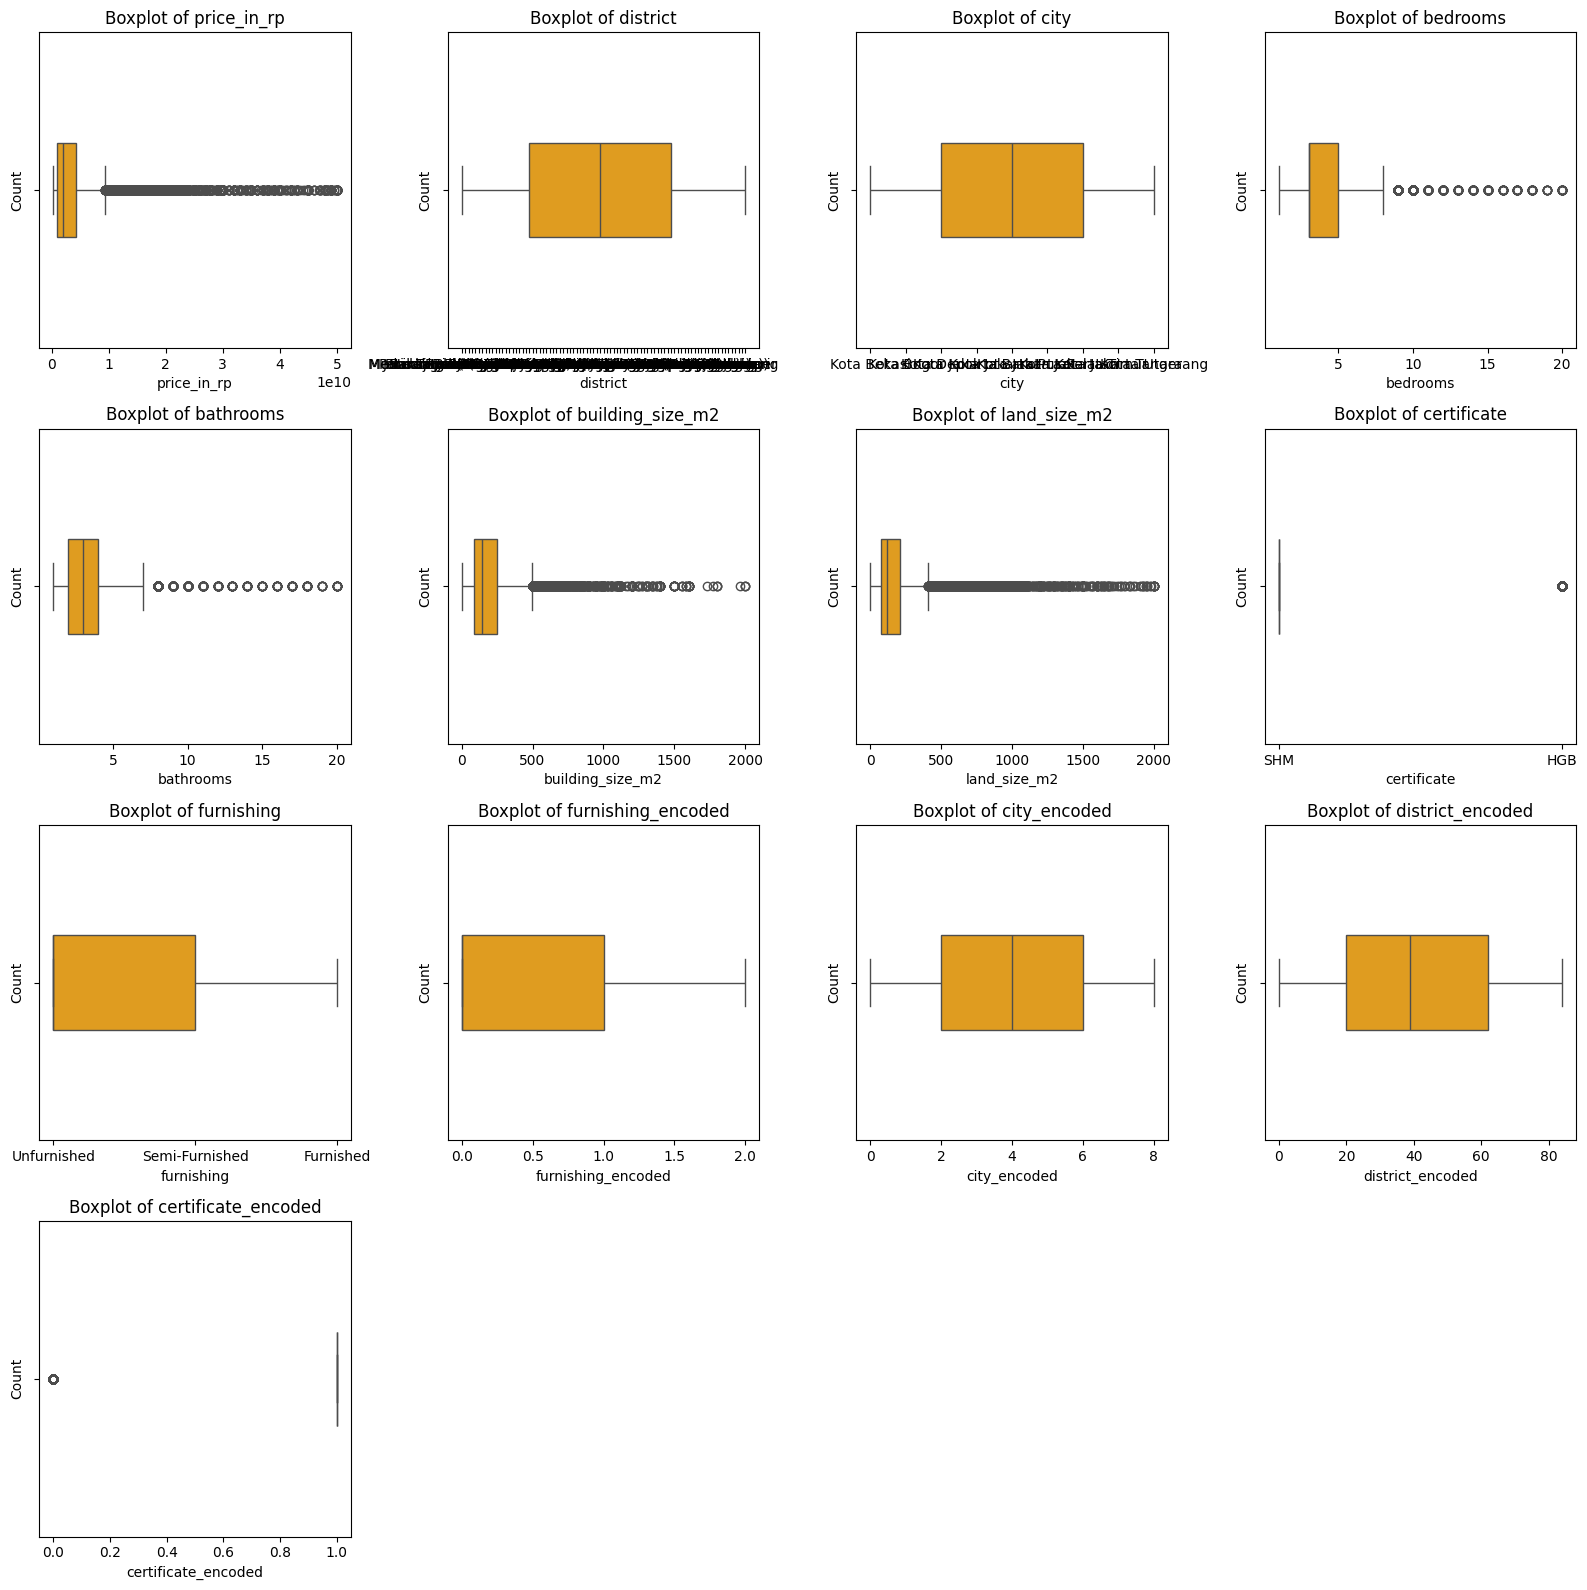

In [510]:
num_cols = 4
num_rows = math.ceil(len(filtered_df.columns) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(filtered_df.columns):
    sns.boxplot(x=filtered_df[col], ax=axes[i], color='orange', width=0.3)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    
for j in range(len(filtered_df.columns), len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

In [511]:
def handle_outliers(df, columns):
    df_no_outliers = df.copy()
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR

        print(f"lower_bound: {lower_bound}, upper_bound: {upper_bound} for column {column}")
        
        outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
        outliers_count = outlier_mask.sum()
        print(f"Column {column}: {outliers_count} outliers detected\n")
        df_no_outliers = df_no_outliers[~outlier_mask]
    
    print(f"\nShape before outlier removal: {df.shape}")
    print(f"Shape after outlier removal: {df_no_outliers.shape}")
    
    return df_no_outliers

columns_to_check = ['price_in_rp', 'land_size_m2', 'building_size_m2', 'bedrooms', 'bathrooms']
clean_df = handle_outliers(filtered_df, columns_to_check)

lower_bound: -5633000000.0, upper_bound: 10922000000.0 for column price_in_rp
Column price_in_rp: 2219 outliers detected

lower_bound: -184.0, upper_bound: 476.0 for column land_size_m2
Column land_size_m2: 2023 outliers detected

lower_bound: -248.0, upper_bound: 582.0 for column building_size_m2
Column building_size_m2: 1284 outliers detected

lower_bound: -1.0, upper_bound: 9.0 for column bedrooms
Column bedrooms: 538 outliers detected

lower_bound: -2.0, upper_bound: 8.0 for column bathrooms
Column bathrooms: 344 outliers detected


Shape before outlier removal: (27966, 13)
Shape after outlier removal: (24352, 13)


C:\Users\Baraja\AppData\Local\Temp\ipykernel_6500\2773303482.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_no_outliers = df_no_outliers[~outlier_mask]
C:\Users\Baraja\AppData\Local\Temp\ipykernel_6500\2773303482.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_no_outliers = df_no_outliers[~outlier_mask]
C:\Users\Baraja\AppData\Local\Temp\ipykernel_6500\2773303482.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_no_outliers = df_no_outliers[~outlier_mask]
C:\Users\Baraja\AppData\Local\Temp\ipykernel_6500\2773303482.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_no_outliers = df_no_outliers[~outlier_mask]


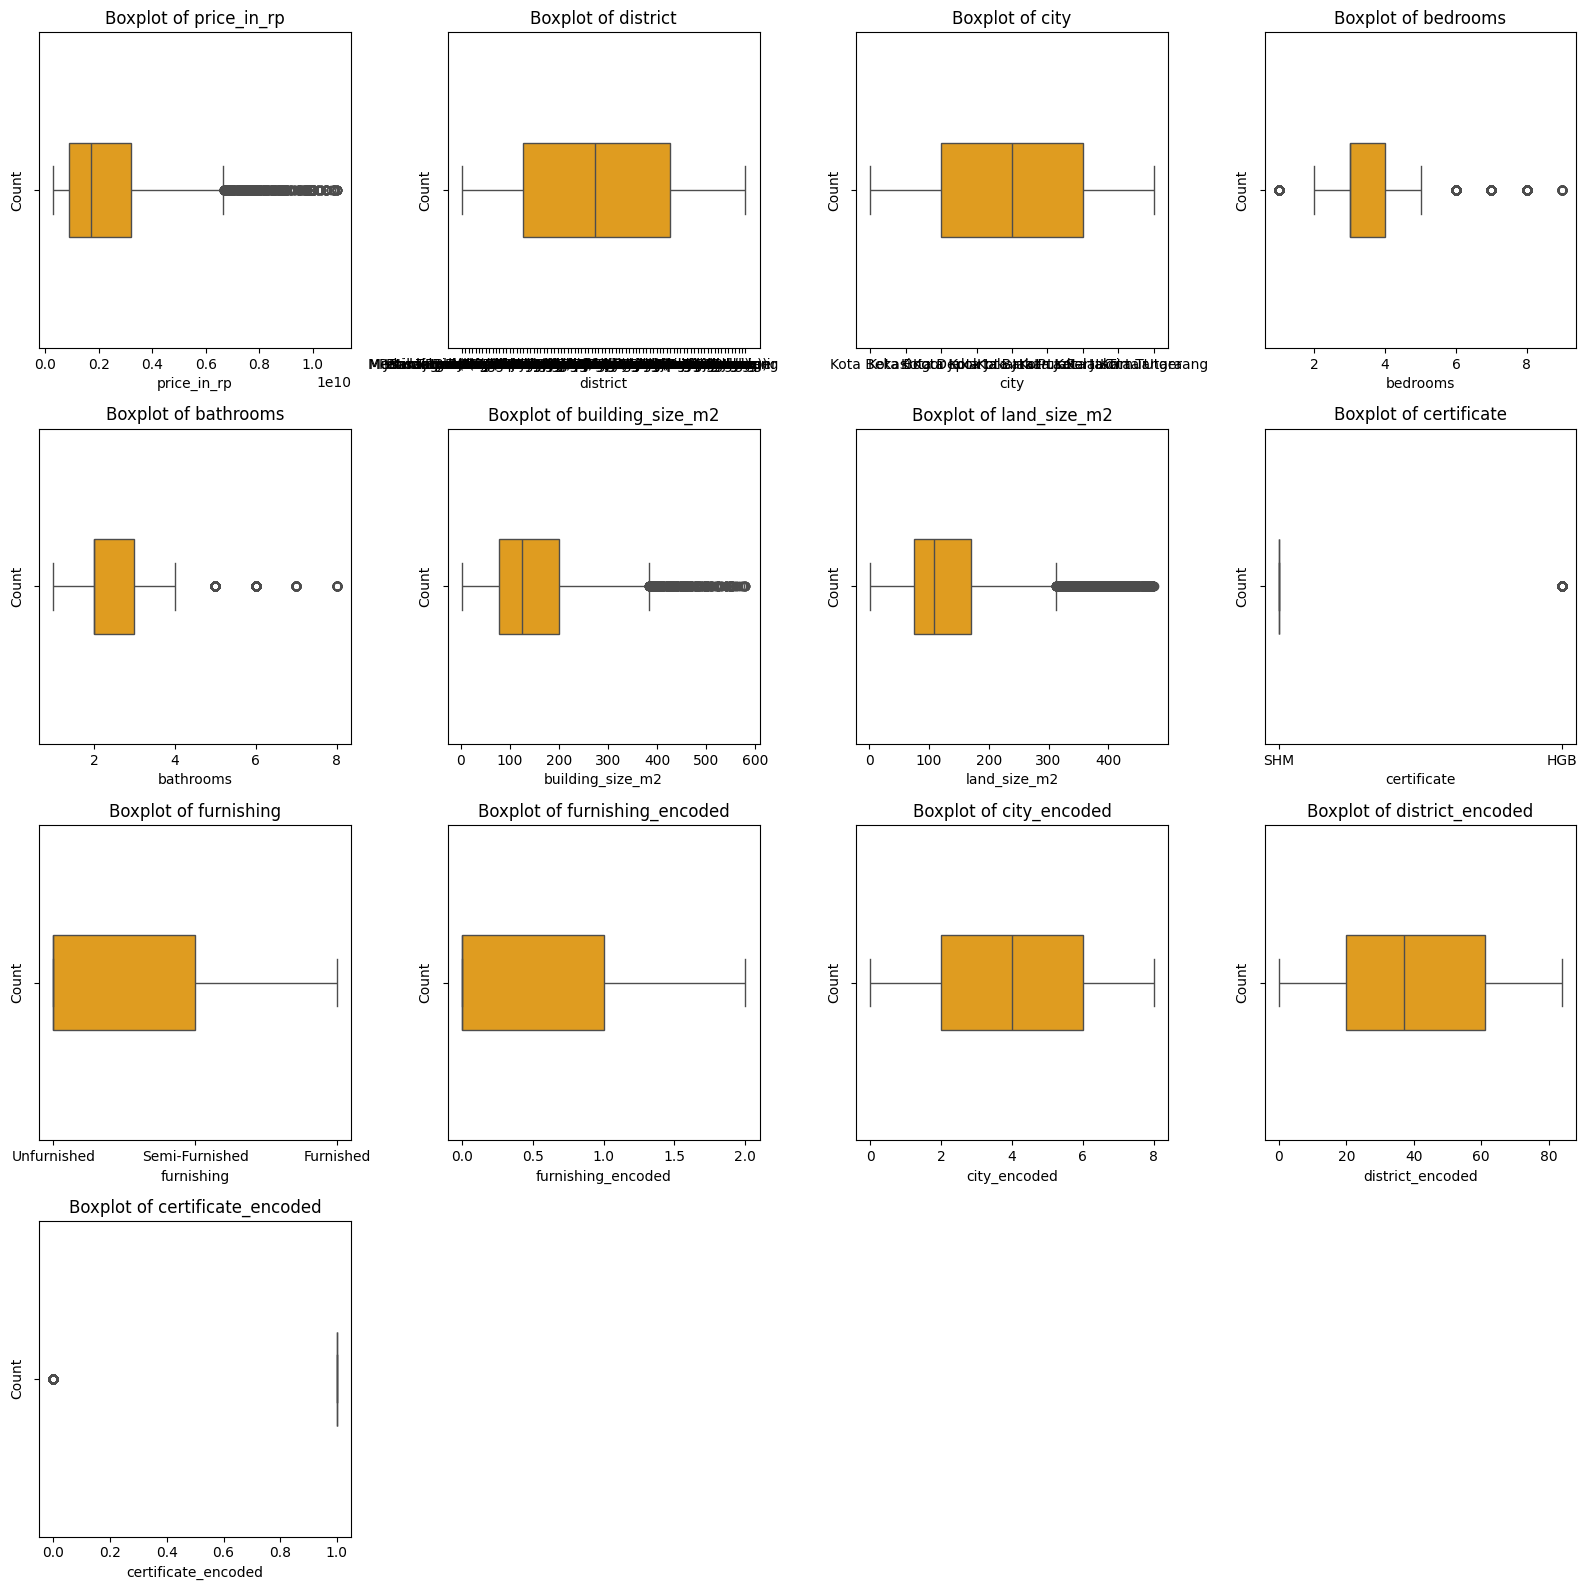

In [512]:
num_cols = 4
num_rows = math.ceil(len(clean_df.columns) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(clean_df.columns):
    sns.boxplot(x=clean_df[col], ax=axes[i], color='orange', width=0.3)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    
for j in range(len(clean_df.columns), len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

### **2.5. Show Correlations Heatmap**

In [513]:
clean_df = filtered_df.drop(['city', 'district', 'certificate', 'furnishing'], axis=1)
clean_df.head()

,price_in_rp,bedrooms,bathrooms,building_size_m2,land_size_m2,furnishing_encoded,city_encoded,district_encoded,certificate_encoded
0,1343000000,2.0,1.0,39.0,70.0,0,0,56,1
2,2290000000,2.0,1.0,48.0,40.0,0,0,54,0
3,1800000000,3.0,2.0,110.0,90.0,1,0,3,1
4,949500000,3.0,2.0,70.0,63.0,0,0,71,1
5,1440000000,3.0,3.0,108.0,91.0,0,0,68,1


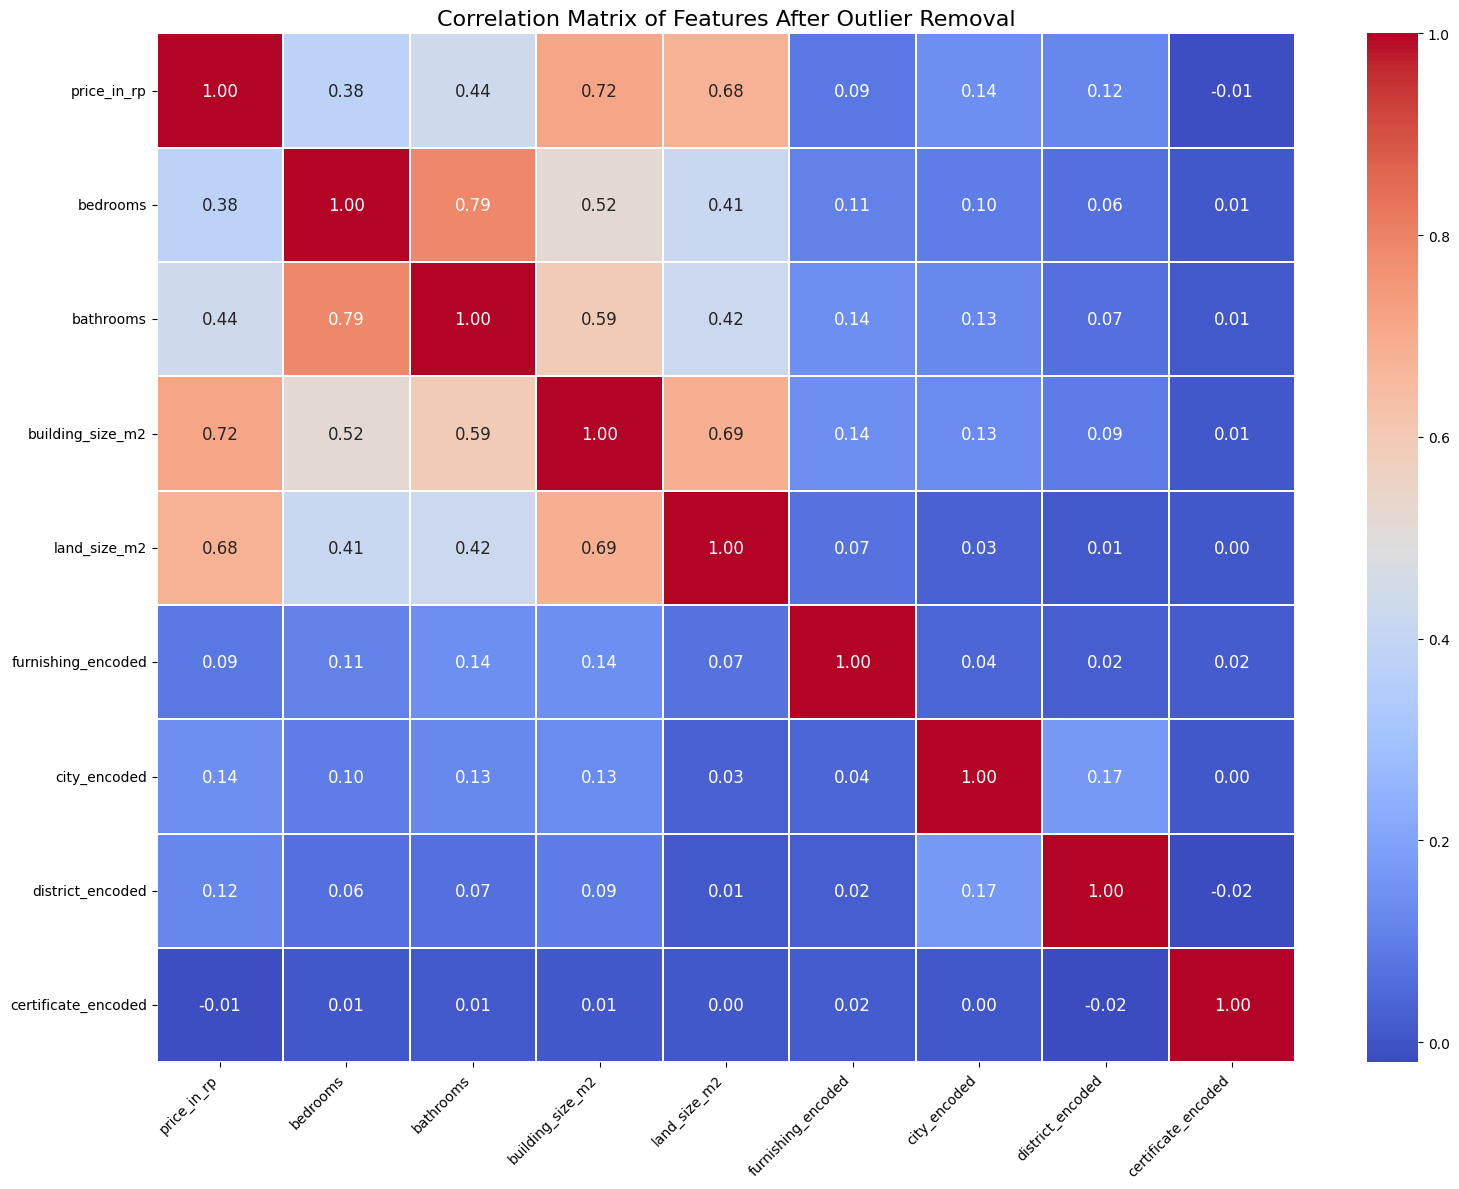

In [514]:
plt.figure(figsize=(16, 12))
sns.heatmap(clean_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.3, annot_kws={"size": 12})
plt.title('Correlation Matrix of Features After Outlier Removal', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# **3. Random Forest Regression**

### **3.1. Features Selection**

In [515]:
features = clean_df.drop(['price_in_rp', 'furnishing_encoded', 'certificate_encoded'], axis=1)
prices = clean_df['price_in_rp']

print("Features shape:", features.shape)
print("Prices shape:", prices.shape)

Features shape: (27966, 6)
Prices shape: (27966,)


### **3.2. Data Normalization**

In [516]:
X_scaler = RobustScaler()
y_scaler = RobustScaler()

X_train, X_test, y_train, y_test = train_test_split(features, prices, test_size=0.2, random_state=42, stratify=clean_df['city_encoded'])

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

In [517]:
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train_scaled shape: {y_train_scaled.shape}")
print(f"y_test_scaled shape: {y_test_scaled.shape}")

X_train_scaled shape: (22372, 6)
X_test_scaled shape: (5594, 6)
y_train_scaled shape: (22372,)
y_test_scaled shape: (5594,)


### **3.3. Train RFR Model**

In [518]:
# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 'log2']
}

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for Random Forest Regression...")
print("This may take a few minutes...")

grid = list(ParameterGrid(param_grid))
best_score = float('-inf')
best_params = None
# best_params = {
#     'n_estimators': 300,
#     'max_depth': 30,
#     'min_samples_split': 5,
#     'min_samples_leaf': 2,
#     'max_features': 'sqrt'
# }

# Gunakan tqdm di dalam for loop biasa
for params in tqdm.tqdm(grid, desc="Grid Search Progress"):
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    
    # Hitung rata-rata cross validation score untuk kombinasi parameter ini
    scores = cross_val_score(model, X_train_scaled, y_train_scaled, 
                             scoring='neg_mean_absolute_error', cv=5)
    mean_score = np.mean(scores)
    
    # Simpan jika skornya lebih baik
    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print(f"\nBest parameters: {best_params}")
print(f"Best cross-validation score: {-best_score:.4f}")

# Train model final dengan parameter terbaik
best_rf_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train_scaled, y_train_scaled)

Starting GridSearchCV for Random Forest Regression...
This may take a few minutes...


Grid Search Progress: 100%|██████████| 162/162 [09:25<00:00,  3.49s/it]



Best parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validation score: 0.3523


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

# **4. Model Evaluation**

### **4.1. RFR Evaluation**

In [519]:
# Make predictions with the best model
y_pred_train = best_rf_model.predict(X_train_scaled)
y_pred_test = best_rf_model.predict(X_test_scaled)

# Calculate metrics for training set
train_mae = mean_absolute_error(y_train_scaled, y_pred_train)
train_rmse = root_mean_squared_error(y_train_scaled, y_pred_train)
train_r2 = r2_score(y_train_scaled, y_pred_train)
train_mape = mean_absolute_percentage_error(y_train_scaled, y_pred_train)

# Calculate metrics for test set
test_mae = mean_absolute_error(y_test_scaled, y_pred_test)
test_rmse = root_mean_squared_error(y_test_scaled, y_pred_test)
test_r2 = r2_score(y_test_scaled, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test_scaled, y_pred_test)

# Display results
print("\n" + "="*50)
print("RANDOM FOREST REGRESSION RESULTS")
print("="*50)
print("\nTraining Set Performance:")
print(f"MAE:  {train_mae:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²:   {train_r2:.4f}")
print(f"MAPE: {train_mape:.4f}")

print("\nTest Set Performance:")
print(f"MAE:  {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²:   {test_r2:.4f}")
print(f"MAPE: {test_mape:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"R² difference (Train - Test): {train_r2 - test_r2:.4f}")
if (train_r2 - test_r2) > 0.1:
    print("⚠️  Model may be overfitting")
else:
    print("✅  Model appears to generalize well")


RANDOM FOREST REGRESSION RESULTS

Training Set Performance:
MAE:  0.2208
RMSE: 0.5083
R²:   0.9259
MAPE: 10319275643146.8613

Test Set Performance:
MAE:  0.3330
RMSE: 0.7514
R²:   0.8359
MAPE: 21097310775900.6133

Overfitting Check:
R² difference (Train - Test): 0.0900
✅  Model appears to generalize well


### **4.2. Feature Importance Analysis**


FEATURE IMPORTANCE RANKING
 1. land_size_m2         : 0.3528
 2. building_size_m2     : 0.3060
 3. district_encoded     : 0.1131
 4. city_encoded         : 0.0995
 5. bathrooms            : 0.0769
 6. bedrooms             : 0.0517


C:\Users\Baraja\AppData\Local\Temp\ipykernel_6500\3645847721.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


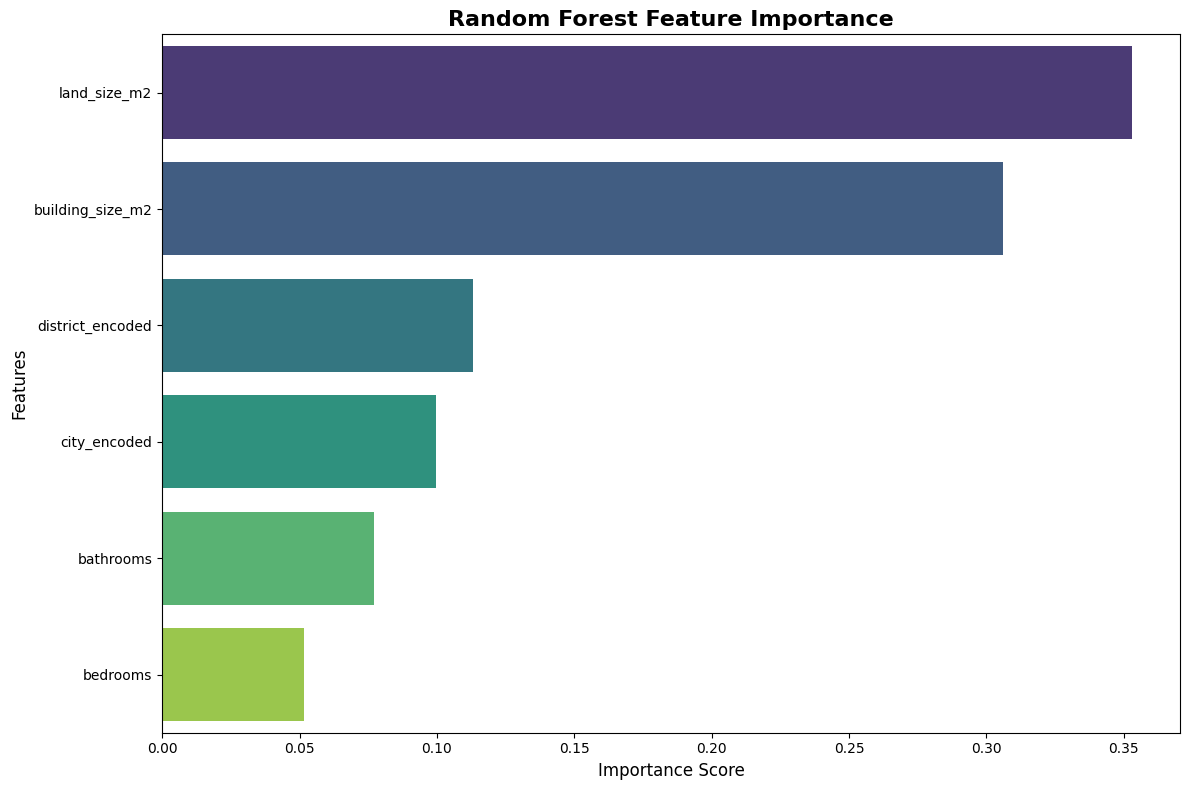

In [520]:
# Feature Importance Analysis
feature_importance = best_rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\n" + "="*40)
print("FEATURE IMPORTANCE RANKING")
print("="*40)
for i, (feature, importance) in enumerate(zip(importance_df['Feature'], importance_df['Importance']), 1):
    print(f"{i:2d}. {feature:20s} : {importance:.4f}")

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

### **4.3. Predicted vs Actual Data Visualization**

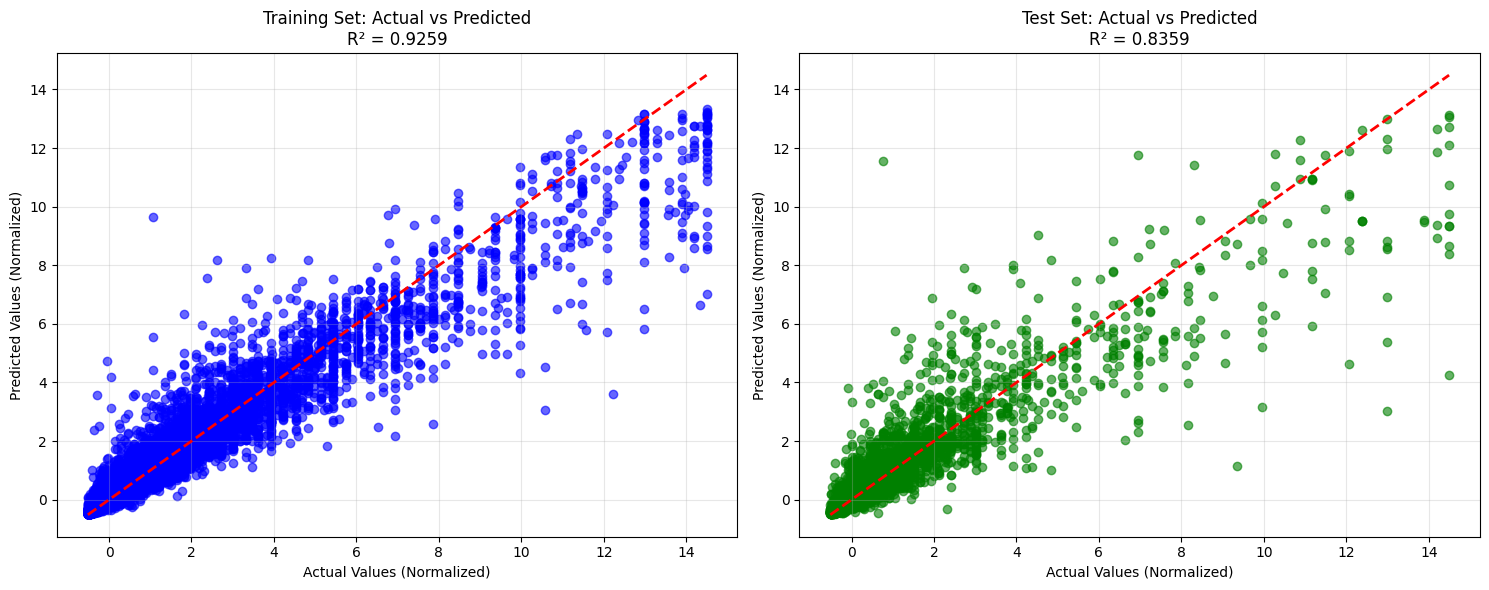

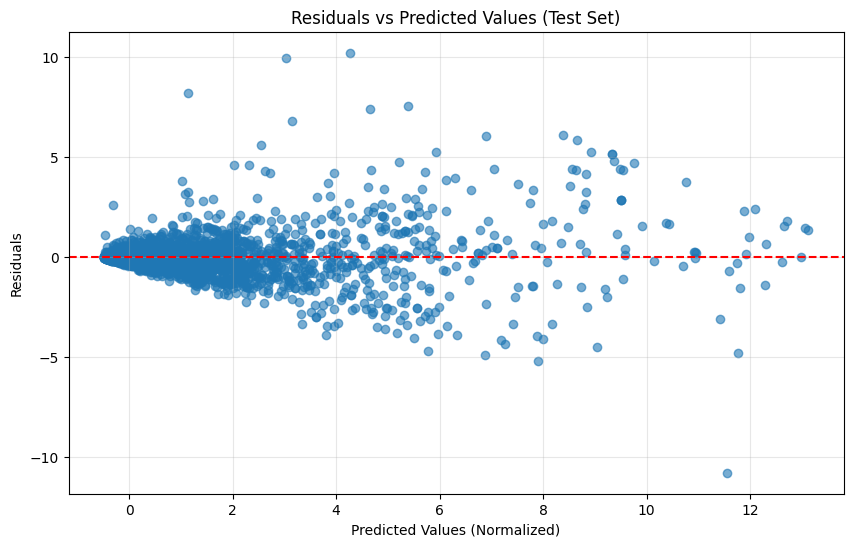

In [521]:
# Prediction vs Actual Values Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Training set
ax1.scatter(y_train_scaled, y_pred_train, alpha=0.6, color='blue')
ax1.plot([y_train_scaled.min(), y_train_scaled.max()], 
         [y_train_scaled.min(), y_train_scaled.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Values (Normalized)')
ax1.set_ylabel('Predicted Values (Normalized)')
ax1.set_title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}')
ax1.grid(True, alpha=0.3)

# Test set
ax2.scatter(y_test_scaled, y_pred_test, alpha=0.6, color='green')
ax2.plot([y_test_scaled.min(), y_test_scaled.max()], 
         [y_test_scaled.min(), y_test_scaled.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Values (Normalized)')
ax2.set_ylabel('Predicted Values (Normalized)')
ax2.set_title(f'Test Set: Actual vs Predicted\nR² = {test_r2:.4f}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residuals plot
residuals_test = y_test_scaled - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals_test, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values (Normalized)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values (Test Set)')
plt.grid(True, alpha=0.3)
plt.show()

# **5. Export Model**

In [522]:
# Buat folder jika belum ada
os.makedirs('../../models', exist_ok=True)

# Export model dan scaler menggunakan joblib
joblib.dump(best_rf_model, '../../models/best_rf_model.joblib')
joblib.dump(X_scaler, '../../models/X_scaler.joblib')
joblib.dump(y_scaler, '../../models/y_scaler.joblib')
joblib.dump(furnishing_encoder, '../../models/furnishing_encoder.joblib')
joblib.dump(city_encoder, '../../models/city_encoder.joblib')
joblib.dump(district_encoder, '../../models/district_encoder.joblib')
joblib.dump(certificate_encoder, '../../models/certificate_encoder.joblib')

# Buat dictionary metadata
model_metadata = {
    'model_type': 'RandomForestRegressor',
    'best_parameters': best_params,
    'best_cv_score': -best_score,
    'test_metrics': {
        'mae': test_mae,
        'rmse': test_rmse,
        'r2': test_r2,
        'mape': test_mape
    },
    'train_metrics': {
        'mae': train_mae,
        'rmse': train_rmse,
        'r2': train_r2,
        'mape': train_mape
    },
    'feature_names': list(X_train.columns),
    'feature_importance': dict(zip(X_train.columns, feature_importance))
}

# Export metadata
joblib.dump(model_metadata, '../../models/model_metadata.joblib')

print("✅ Model Export Completed!")
print("📁 Saved files:")
print("   • ../../models/best_rf_model.joblib - Trained Random Forest model")
print("   • ../../models/X_scaler.joblib - Feature scaler")
print("   • ../../models/y_scaler.joblib - Target scaler")
print("   • ../../models/city_encoder.joblib - Label encoder for city")
print("   • ../../models/district_encoder.joblib - Label encoder for district")
print("   • ../../models/model_metadata.joblib - Model information and metrics")
print(f"\n📊 Model Performance Summary:")
print(f"   • Test R²: {test_r2:.4f}")
print(f"   • Test MAE: {test_mae:.4f}")
print(f"   • Test RMSE: {test_rmse:.4f}")
print(f"   • Best CV Score: {-best_score:.4f}")

✅ Model Export Completed!
📁 Saved files:
   • ../../models/best_rf_model.joblib - Trained Random Forest model
   • ../../models/X_scaler.joblib - Feature scaler
   • ../../models/y_scaler.joblib - Target scaler
   • ../../models/city_encoder.joblib - Label encoder for city
   • ../../models/district_encoder.joblib - Label encoder for district
   • ../../models/model_metadata.joblib - Model information and metrics

📊 Model Performance Summary:
   • Test R²: 0.8359
   • Test MAE: 0.3330
   • Test RMSE: 0.7514
   • Best CV Score: 0.3523


# **6. Testing Model**

In [523]:
# Example: How to load and use the saved model for predictions
print("\n" + "="*50)
print("EXAMPLE: Loading and Using Saved Model")
print("="*50)

# Load the saved model and scalers
loaded_model = joblib.load('../../models/best_rf_model.joblib')
loaded_X_scaler = joblib.load('../../models/X_scaler.joblib')
loaded_y_scaler = joblib.load('../../models/y_scaler.joblib')
loaded_city_encoder = joblib.load('../../models/city_encoder.joblib')
loaded_district_encoder = joblib.load('../../models/district_encoder.joblib')
loaded_metadata = joblib.load('../../models/model_metadata.joblib')

print("✅ Model loaded successfully!")
print(f"📋 Model Type: {loaded_metadata['model_type']}")
print(f"🔧 Features used: {len(loaded_metadata['feature_names'])}")
print(f"🎯 Test R² Score: {loaded_metadata['test_metrics']['r2']:.4f}")

# Example prediction on a single sample from test set
sample_index = 0
sample_features = X_test.iloc[sample_index:sample_index+1]
actual_price = y_test.iloc[sample_index]

# Scale the features
sample_scaled = loaded_X_scaler.transform(sample_features)

# Make prediction (scaled)
prediction_scaled = loaded_model.predict(sample_scaled)

# Inverse transform to get actual price
predicted_price = loaded_y_scaler.inverse_transform(prediction_scaled.reshape(-1, 1))[0][0]

print(f"\n🏠 Example Prediction:")
print(f"   Actual Price: Rp {actual_price:,.0f}")
print(f"   Predicted Price: Rp {predicted_price:,.0f}")
print(f"   Error: Rp {abs(actual_price - predicted_price):,.0f}")
print(f"   Error %: {abs(actual_price - predicted_price)/actual_price*100:.2f}%")


EXAMPLE: Loading and Using Saved Model
✅ Model loaded successfully!
📋 Model Type: RandomForestRegressor
🔧 Features used: 6
🎯 Test R² Score: 0.8359

🏠 Example Prediction:
   Actual Price: Rp 15,000,000,000
   Predicted Price: Rp 16,253,131,414
   Error: Rp 1,253,131,414
   Error %: 8.35%


In [524]:
# Create a prediction function for new house data
def predict_house_price(land_size, building_size, bedrooms, bathrooms, city, district):
    """
    Predict house price using the trained Random Forest model
    
    Parameters:
    - land_size: Land size in m²
    - building_size: Building size in m²
    - bedrooms: Number of bedrooms
    - bathrooms: Number of bathrooms
    - city: City encoded as integer (use city_encoder to transform)
    - district: District encoded as integer (use district_encoder to transform)
    
    Returns:
    - Predicted price in Indonesian Rupiah
    """
    
    # Encode categorical features
    city_encoded = city_encoder.transform([city])[0]
    district_encoded = district_encoder.transform([district])[0]
    
    # Create input array in the correct order
    input_data = np.array([[land_size, building_size, bedrooms, bathrooms, city_encoded, district_encoded]])
    
    # Scale the input
    input_scaled = loaded_X_scaler.transform(input_data)
    
    # Make prediction
    prediction_scaled = loaded_model.predict(input_scaled)
    
    # Inverse transform to get actual price
    predicted_price = loaded_y_scaler.inverse_transform(prediction_scaled.reshape(-1, 1))[0][0]
    
    return predicted_price

In [525]:
# Example usage of the prediction function
print("\n" + "="*50)
print("PREDICTION FUNCTION EXAMPLE")
print("="*50)

# Example house parameters
example_house = {
    'land_size': 120,
    'building_size': 80,
    'bedrooms': 3,
    'bathrooms': 2,
    'city': "Kota Jakarta Selatan",
    'district': "Kebayoran Lama",
}

predicted_price = predict_house_price(**example_house)

print("🏠 Example House Specifications:")
for key, value in example_house.items():
    print(f"   {key}: {value}")

print(f"\n💰 Predicted Price: Rp {predicted_price:,.0f}")


PREDICTION FUNCTION EXAMPLE
🏠 Example House Specifications:
   land_size: 120
   building_size: 80
   bedrooms: 3
   bathrooms: 2
   city: Kota Jakarta Selatan
   district: Kebayoran Lama

💰 Predicted Price: Rp 3,205,214,827


d:\KARYA TULIS\HKI\HomeIQ\backend\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


In [526]:
# Save the prediction function using joblib
joblib.dump(predict_house_price, '../../models/prediction_function.joblib')

print("\n✅ Prediction function saved as 'models/prediction_function.joblib'")


✅ Prediction function saved as 'models/prediction_function.joblib'
